In [330]:
YOUR_NAME = 'sara'

AWS_PROFILE = 'cities'

In [331]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [332]:
MAIN_PATH = "s3://wri-cities-sandbox/identifyingLandSubdivisions/data"
INPUT_PATH = f'{MAIN_PATH}/input'
CITY_INFO_PATH = f'{INPUT_PATH}/city_info'
EXTENTS_PATH = f'{CITY_INFO_PATH}/extents'
BUILDINGS_PATH = f'{INPUT_PATH}/buildings'
BLOCKS_PATH = f'{INPUT_PATH}/blocks'
ROADS_PATH = f'{INPUT_PATH}/roads'
INTERSECTIONS_PATH = f'{INPUT_PATH}/intersections'
GRIDS_PATH = f'{INPUT_PATH}/city_info/grids'
SEARCH_BUFFER_PATH = f'{INPUT_PATH}/city_info/search_buffers'
OUTPUT_PATH = f'{MAIN_PATH}/output'
OUTPUT_PATH_CSV = f'{OUTPUT_PATH}/csv'
OUTPUT_PATH_RASTER = f'{OUTPUT_PATH}/raster'
OUTPUT_PATH_PNG = f'{OUTPUT_PATH}/png'
OUTPUT_PATH_RAW = f'{OUTPUT_PATH}/raw_results'

In [333]:
# Check s3 connection using AWS_PROFILE=CitiesUserPermissionSet profile 
import boto3
boto3.setup_default_session(profile_name='cities')
session = boto3.Session(profile_name=AWS_PROFILE)
s3 = session.client('s3')

# export CitiesUserPermissionSet profile to use in the next cells
import os
os.environ['AWS_PROFILE'] = AWS_PROFILE

s3.list_buckets()

{'ResponseMetadata': {'RequestId': 'AQ0N4D0HS5VB07QF',
  'HostId': 'D6KAeeRxdxRGr8TdPyWVb6qT68ZWRGdZ0JdenogTYQEY3kaI6a1+8uK6R+QfCALQ2++mvM61yOY=',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'D6KAeeRxdxRGr8TdPyWVb6qT68ZWRGdZ0JdenogTYQEY3kaI6a1+8uK6R+QfCALQ2++mvM61yOY=',
   'x-amz-request-id': 'AQ0N4D0HS5VB07QF',
   'date': 'Wed, 25 Mar 2026 01:04:38 GMT',
   'content-type': 'application/xml',
   'transfer-encoding': 'chunked',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'Buckets': [{'Name': 'aft-sandbox-540362055257',
   'CreationDate': datetime.datetime(2022, 9, 13, 15, 12, 20, tzinfo=tzutc()),
   'BucketArn': 'arn:aws:s3:::aft-sandbox-540362055257'},
  {'Name': 'amplify-citiesindicatorsapi-dev-10508-deployment',
   'CreationDate': datetime.datetime(2023, 8, 30, 5, 5, 13, tzinfo=tzutc()),
   'BucketArn': 'arn:aws:s3:::amplify-citiesindicatorsapi-dev-10508-deployment'},
  {'Name': 'cities-heat',
   'CreationDate': datetime.datetime(2023, 6, 1, 13, 22, 1, tzinfo=tzutc

In [334]:
'''
# START COILED CLIENT.

import coiled

cluster = coiled.Cluster(
    workspace="wri-cities-data",
    name=f'ils-{YOUR_NAME}',
    region="us-west-2",
    arm=True,
    worker_vm_types="r8g.xlarge",
    spot_policy="spot",
    n_workers=10,
    package_sync_ignore=["pyspark", "pypandoc",
                         "boto3",
                        "botocore",
                        "aiobotocore",
                        "urllib3"]
)
client = cluster.get_client()

print(f"Started a new Dask client on Coiled. Dashboard is available at {client.dashboard_link}")
'''

'\n# START COILED CLIENT.\n\nimport coiled\n\ncluster = coiled.Cluster(\n    workspace="wri-cities-data",\n    name=f\'ils-{YOUR_NAME}\',\n    region="us-west-2",\n    arm=True,\n    worker_vm_types="r8g.xlarge",\n    spot_policy="spot",\n    n_workers=10,\n    package_sync_ignore=["pyspark", "pypandoc",\n                         "boto3",\n                        "botocore",\n                        "aiobotocore",\n                        "urllib3"]\n)\nclient = cluster.get_client()\n\nprint(f"Started a new Dask client on Coiled. Dashboard is available at {client.dashboard_link}")\n'

In [335]:
import dask_geopandas as dgpd
import dask.dataframe as dd
import pandas as pd
from dask import delayed, compute, visualize
import geopandas as gpd
from dask.diagnostics import ProgressBar
from shapely.geometry import MultiLineString, LineString, Point
from shapely.ops import polygonize, nearest_points
#from shapely.geometry import Polygon, LineString, Point, MultiPolygon, MultiLineString, GeometryCollection
from scipy.optimize import fminbound, minimize
#from unused_code.metrics_groupby import metrics
from dask import delayed
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely import wkb
from scipy.stats import entropy
import time
from dask import compute
import matplotlib.pyplot as plt

import s3fs
import os
import shutil

from pre_processing import *
from auxiliary_functions import *
from standardize_metrics import *
from metrics_calculation import *

import time

YOUR_NAME = 'sara'

In [336]:
def read_validation_set_s3(bucket_prefix = "wri-cities-sandbox/identifyingLandSubdivisions/data/validation/Land_Use/102_cities",
                           base = "Final_102Cities"):
    
    # or use 9_cities/Sub_Saharan_9_cities_and_LAC_3_cities_Land_use
    
    fs = s3fs.S3FileSystem(anon=False)

    # All components of the shapefile
    suffixes = [".shp", ".dbf", ".shx", ".prj", ".cpg"]

    local_dir = "/tmp/land_use"
    os.makedirs(local_dir, exist_ok=True)

    for suf in suffixes:
        s3_path = f"{bucket_prefix}/{base}{suf}"
        local_path = os.path.join(local_dir, base + suf)
        with fs.open(s3_path, "rb") as fsrc, open(local_path, "wb") as fdst:
            shutil.copyfileobj(fsrc, fdst)

    # Now read from local path
    local_shp = os.path.join(local_dir, base + ".shp")
    validation_set = gpd.read_file(local_shp)

    return validation_set

validation_set = read_validation_set_s3()

'''
validation_set["City"] = validation_set["City"].str.replace(
    r'(?<=-)([a-z])', lambda m: m.group(1).upper(), regex=True
)

validation_set["Country"] = validation_set["Country"].str.replace(
    r'(?<=-)([a-z])', lambda m: m.group(1).upper(), regex=True
)
'''

mix = "Democratic_Republic_of_the_Congo_Republic_of_Congo"

# Brazzaville -> Kinshasa
validation_set["City"] = validation_set["City"].mask(validation_set["City"].eq("Brazzaville"), "Kinshasa")

# Set Country to the mixed one for (original) Kinshasa and Brazzaville rows
validation_set["Country"] = validation_set["Country"].mask(
    validation_set["City"].eq("Kinshasa"),  # after the line above, Brazzaville is now Kinshasa too
    mix
)

validation_set.loc[validation_set["City"] == "N_Djamena", "Country"] = "Chad"

cities = validation_set.City.unique()

validation_set[validation_set.Country.isna()]

,City,Date,Label,Area,ObjectID,Country,Land_Use,geometry


In [337]:


MAIN_PATH = "s3://wri-cities-sandbox/identifyingLandSubdivisions/data"
OUTPUT_PATH = f"{MAIN_PATH}/output"
OUTPUT_PATH_RASTER = f"{OUTPUT_PATH}/raster"


repl = {
        "United Republic of Tanzania": "Tanzania",
        "Congo": "Republic of Congo",
        "Pointe-Noire": "Pointe Noire",
        "Côte d'Ivoire": "Cote d Ivoire",
        "CÃ´te d'Ivoire": "Cote d Ivoire",
        "Cã´Te-D'Ivoire" : "Cote d Ivoire",
        "Mbour": "MBour",
        "Manzin": "Manzini",
        "Burkina-Faso":"Burkina Faso",
        "Sierra-Leone":"Sierra Leone",
        "South-Africa": "South Africa",
        "Guinea-Bissau": "Guinea Bissau",
        "Ido ekiti":"Ido Ekiti",
        'Port-gentil':"Port Gentil"
            }

validation_set[["City", "Country"]] = validation_set[["City", "Country"]].replace(repl)


cities = validation_set[['City','Country']].drop_duplicates().apply(lambda x: "_".join(x['City'].split())+'__'+"_".join(x['Country'].split()), axis=1).values 

cities = list(set(cities) - set(['Banki__Nigeria', 'Maseru__South_Africa', 'Lome__Ghana','N_Djamena__Cameroon']))



In [338]:
dfs = []
for city_name in cities:
    out_file = f"{city_name}_block_metrics_ALL_{YOUR_NAME}.geoparquet"
    remote = f"{OUTPUT_PATH_RASTER}/{city_name}/{out_file}"
    df_tmp = gpd.read_parquet(remote).to_crs(epsg=4326)
    df_tmp["city_name"] = city_name
    dfs.append(df_tmp)


all_cities = pd.concat(dfs)
all_cities = all_cities.rename(columns={'k_k_complexity': 'k_complexity_raw'})


In [339]:
all_cities.columns

Index(['geometry', 'optimal_point', 'max_radius', 'block_area',
       'block_area_km2', 'built_area', 'n_buildings', 'index', 'total_len_m',
       'road_length', 'has_roads', 'n_intersections', 'intersections_3plus',
       'intersections_4way', 'has_intersections', 'm3_raw', 'm3_std', 'm4_raw',
       'm4_std', 'm5_raw', 'm5_std', 'm10_raw', 'm10_std', 'm11_raw',
       'm11_std', 'm12_raw', 'm12_std', 'sum_distance', 'n_closer_20m',
       'has_buildings', 'average_distance_nearest_building', 'm1_raw',
       'm1_std', 'm2_raw', 'm2_std', 'm6_raw', 'm6_std', 'm7_raw', 'm7_std',
       'm8_raw', 'm8_std', 'm9_raw', 'm9_std', 'k_on_network_street_length',
       'k_off_network_street_length', 'k_nearest_external_street',
       'k_building_count', 'k_building_layers', 'k_complexity_raw',
       'city_name', 'is_fill_block', 'fill_method', 'm9_n_intersections'],
      dtype='object')

In [340]:
metrics_std = ['m1_std','m2_std','m3_std','m4_std','m5_std','m6_std',
               'm7_std','m8_std','m9_std','k_complexity_std','m10_std','m11_std','m12_std']

metrics_final = ['m{i}_final'.format(i=i) for i in range(1,13)] + ['k_complexity_final']

# Resembling new standardization approaches to these two metrics
all_cities['m3_std'] = np.where(all_cities['m3_raw'] > 80, 80, all_cities['m3_raw'])
all_cities['m3_std'] =  all_cities['m3_std']/80
all_cities['k_complexity_std'] =  np.where(all_cities['k_complexity_raw'] > 10, 10, all_cities['k_complexity_raw'])
all_cities['k_complexity_std'] = 1 - (all_cities['k_complexity_std']/10.)


means = all_cities[metrics_std].mean()
stds  = all_cities[metrics_std].std()
mins  = all_cities[metrics_std].min()
maxs  = all_cities[metrics_std].max()


all_cities[metrics_final] = (all_cities[metrics_std] - all_cities[metrics_std].min()) / (all_cities[metrics_std].max() - all_cities[metrics_std].min())

    

In [341]:
print(len(all_cities))
all_cities = all_cities[all_cities.block_area>=700]
print(len(all_cities))
all_cities = all_cities[all_cities.n_buildings>0]
print(len(all_cities))
890115/952001

952001
940067
890115


0.9349937657628511

In [342]:
all_cities['m3_raw'].describe()

count    890115.000000
mean         79.086340
std          46.616303
min           0.000000
25%          44.261654
50%          70.910095
75%         102.859334
max        1073.000564
Name: m3_raw, dtype: float64

In [343]:
all_cities['k_complexity_raw'].describe()

count    889926.000000
mean          2.379457
std           1.062852
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          49.000000
Name: k_complexity_raw, dtype: float64

In [344]:
summary = (
    all_cities
    .groupby('city_name')['k_complexity_raw']
    .describe()
)
summary

,count,mean,std,min,25%,50%,75%,max
city_name,,,,,,,,
Abidjan__Cote_d_Ivoire,19512.0,2.209051,0.926500,1.0,2.0,2.0,3.0,14.0
Accra__Ghana,41758.0,2.430672,0.978452,1.0,2.0,2.0,3.0,23.0
Addis_Ababa__Ethiopia,28039.0,2.310246,1.022644,1.0,2.0,2.0,3.0,16.0
Ambovombe__Madagascar,112.0,3.267857,1.381878,1.0,2.0,3.0,4.0,7.0
Antananarivo__Madagascar,1925.0,4.100779,3.175109,1.0,2.0,3.0,5.0,34.0
...,...,...,...,...,...,...,...,...
Whydah__Benin,744.0,2.463710,1.098770,1.0,2.0,2.0,3.0,7.0
Windhoek__Namibia,1696.0,2.995283,1.427493,1.0,2.0,3.0,3.0,19.0
Worcester__South_Africa,732.0,2.341530,0.710116,1.0,2.0,2.0,3.0,7.0


In [345]:
pd.crosstab(all_cities['city_name'], all_cities['is_fill_block'], margins=True,dropna=False)

is_fill_block,False,True,NaN,All
city_name,,,,
Abidjan__Cote_d_Ivoire,19452,60,0,19512
Accra__Ghana,41686,72,0,41758
Addis_Ababa__Ethiopia,0,0,28039,28039
Ambovombe__Madagascar,0,0,112,112
Antananarivo__Madagascar,0,0,1925,1925
...,...,...,...,...
Windhoek__Namibia,0,0,1696,1696
Worcester__South_Africa,0,0,732,732
Yaounde__Cameroon,0,0,9739,9739


/var/folders/nn/3mdkp6sx1n3d955f3wqgdbb00000gn/T/ipykernel_82334/1974236939.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


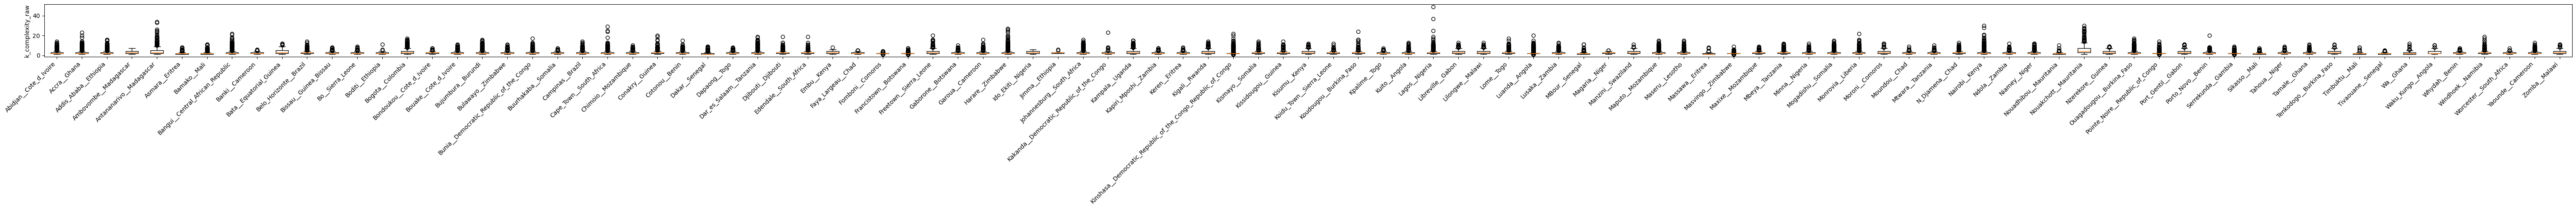

In [346]:
groups = all_cities.groupby('city_name')['k_complexity_raw']

plt.figure(figsize=(max(8, len(groups) * 0.6), 5))

plt.boxplot(
    [g.dropna().values for _, g in groups],
    labels=groups.groups.keys()
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("k_complexity_raw")
plt.tight_layout()
plt.show()


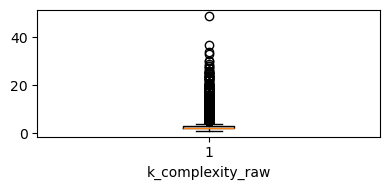

In [347]:


plt.figure(figsize=(4, 2))

plt.boxplot(
    all_cities['k_complexity_raw'].dropna(),
    
    vert=True
)

plt.xlabel("k_complexity_raw")
plt.tight_layout()
plt.show()


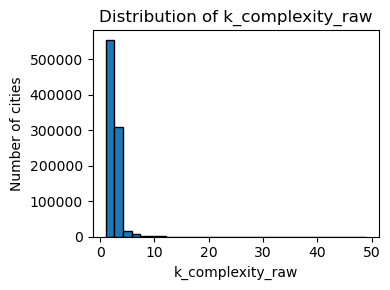

In [348]:
plt.figure(figsize=(4, 3))

plt.hist(
    all_cities['k_complexity_raw'].dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlabel("k_complexity_raw")
plt.ylabel("Number of cities")
plt.title("Distribution of k_complexity_raw")
plt.tight_layout()
plt.show()


In [349]:
all_cities[['k_complexity_raw']].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,k_complexity_raw
0.25,2.0
0.50,2.0
0.75,3.0
0.90,3.0
0.95,4.0
0.99,6.0


In [350]:
all_cities[['m1_raw','m2_raw','m3_raw','m4_raw','m5_raw','m6_raw','m7_raw','m8_raw','m9_raw','m10_raw','m11_raw','m12_raw']].describe()

,m1_raw,m2_raw,m3_raw,m4_raw,m5_raw,m6_raw,m7_raw,m8_raw,m9_raw,m10_raw,m11_raw,m12_raw
count,890115.000000,890115.000000,890115.000000,890115.000000,890115.000000,889926.000000,889926.000000,889926.000000,888301.000000,890115.000000,8.901150e+05,890115.000000
mean,0.786188,14.177373,79.086340,0.266098,482.303316,0.685537,97.550016,0.971534,18.199149,3009.228716,2.316534e-01,106.318482
std,0.216088,12.439712,46.616303,0.307643,483.242154,0.176025,105.120791,0.061425,44.876765,2834.877082,1.342002e-01,213.768253
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.240315,2.783649,0.000000,0.000005,0.423917,1.044175e-08,0.000039
25%,0.656124,8.384585,44.261654,0.000000,177.866450,0.565262,53.224388,0.966622,3.668374,1397.181217,1.288737e-01,57.712907
50%,0.833333,11.973950,70.910095,0.200000,344.293066,0.698428,71.855365,0.995724,7.983548,2463.880408,2.258724e-01,83.468869
75%,1.000000,16.441279,102.859334,0.500000,623.278785,0.800585,102.288276,0.999943,14.197878,3802.191612,3.200900e-01,117.792181
max,1.000000,968.733098,1073.000564,1.000000,9673.963235,1.000000,5510.958818,1.000000,270.000000,60262.076248,1.314628e+00,49163.285430


In [351]:
all_cities[['m1_std','m2_std','m3_std','m4_std','m5_std','m6_std','m7_std','m8_std','m9_std','m10_std','m11_std','m12_std']].describe()

,m1_std,m2_std,m3_std,m4_std,m5_std,m6_std,m7_std,m8_std,m9_std,m10_std,m11_std,m12_std
count,890115.000000,890115.000000,890115.000000,890115.000000,890115.000000,889926.000000,889926.000000,889926.000000,888301.000000,890115.000000,890115.000000,8.901150e+05
mean,0.786188,0.859644,0.769802,0.266098,0.770971,0.685537,0.671064,0.975940,0.797787,0.388696,0.768347,4.613413e-01
std,0.216088,0.101596,0.262030,0.307643,0.309255,0.176025,0.271819,0.037830,0.498631,0.311923,0.134200,2.313996e-01
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.240315,0.000000,0.850000,-2.000000,0.000000,-0.314628,1.937225e-07
25%,0.656124,0.835587,0.553271,0.000000,0.548971,0.565262,0.574775,0.966622,0.842246,0.049452,0.679910,2.885645e-01
50%,0.833333,0.880260,0.886376,0.200000,1.000000,0.698428,0.753792,0.995724,0.911294,0.384030,0.774128,4.173443e-01
75%,1.000000,0.916154,1.000000,0.500000,1.000000,0.800585,0.863386,0.999943,0.959240,0.650705,0.871126,5.889609e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.999894,1.000000,1.000000e+00


In [352]:
#all_cities[all_cities['m9_std']<0]['m9_raw'].describe() # 90 a 270 raw angle: m9 under 0
all_cities[all_cities['m9_std']>0]['m9_raw'].describe() #0 a 90 raw angle: m9 over 0

count    849889.000000
mean          9.356317
std           9.191384
min           0.000005
25%           3.668374
50%           7.535963
75%          12.256186
max          90.000000
Name: m9_raw, dtype: float64

<Axes: >

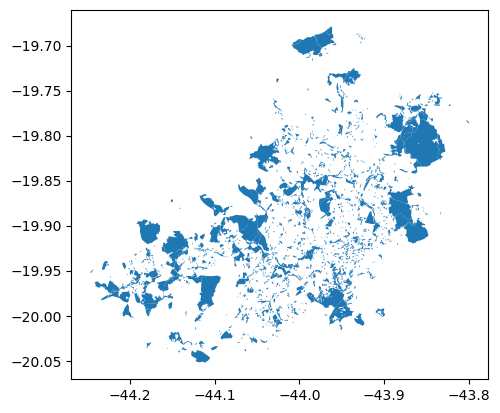

In [353]:
all_cities[(all_cities['city_name']=='Belo_Horizonte__Brazil')&(all_cities['m9_std']<0)].plot()

# Comparing validation polygons and blocks

In [354]:
import geopandas as gpd
import pandas as pd

def summarize_block_validation_overlap(
    all_cities: gpd.GeoDataFrame,
    validation_set: gpd.GeoDataFrame,
    equal_area_epsg: int = 6933
):
    # -----------------------------
    # 1) keep copies + valid geoms
    # -----------------------------
    blocks = all_cities.copy()
    vals = validation_set.copy()

    blocks = blocks[blocks.geometry.notnull() & ~blocks.geometry.is_empty].copy()
    vals = vals[vals.geometry.notnull() & ~vals.geometry.is_empty].copy()

    # optional ids
    blocks = blocks.reset_index(drop=True)
    vals = vals.reset_index(drop=True)
    blocks["block_id"] = blocks.index
    vals["val_id"] = vals.index

    # -----------------------------
    # 2) common projected CRS
    # -----------------------------
    if blocks.crs is None or vals.crs is None:
        raise ValueError("Both GeoDataFrames must have a CRS.")

    blocks = blocks.to_crs(equal_area_epsg)
    vals = vals.to_crs(equal_area_epsg)

    # -----------------------------
    # 3) compute original areas
    # -----------------------------
    blocks["block_area"] = blocks.geometry.area
    vals["val_area"] = vals.geometry.area

    total_block_area = blocks["block_area"].sum()
    total_val_area = vals["val_area"].sum()
    n_blocks_total = len(blocks)
    n_vals_total = len(vals)

    # -----------------------------
    # 4) intersections
    # -----------------------------
    inter = gpd.overlay(
        blocks[["block_id", "block_area", "geometry"]],
        vals[["val_id", "val_area", "geometry"]],
        how="intersection"
    )

    inter = inter[inter.geometry.notnull() & ~inter.geometry.is_empty].copy()
    inter["inter_area"] = inter.geometry.area
    inter = inter[inter["inter_area"] > 0].copy()

    # -----------------------------
    # 5) single global number:
    #    share of validation area
    #    covered by blocks
    # -----------------------------
    covered_val = inter.groupby("val_id", as_index=False)["inter_area"].sum()
    covered_val = covered_val.merge(
        vals[["val_id", "val_area"]],
        on="val_id",
        how="left"
    )
    covered_val["covered_val_area_capped"] = covered_val[["inter_area", "val_area"]].min(axis=1)

    total_validation_area_covered_by_blocks = covered_val["covered_val_area_capped"].sum()
    share_validation_area_covered_by_blocks = (
        total_validation_area_covered_by_blocks / total_val_area
        if total_val_area > 0 else pd.NA
    )

    # -----------------------------
    # 6) block-level outputs:
    #    for intersecting blocks
    # -----------------------------
    block_summary = (
        inter.groupby("block_id", as_index=False)
        .agg(
            validation_polygons_intersecting=("val_id", "nunique"),
            validation_area_on_block=("inter_area", "sum")
        )
        .merge(
            blocks[["block_id", "block_area"]],
            on="block_id",
            how="left"
        )
    )

    block_summary["validation_cover_share_of_block"] = (
        block_summary["validation_area_on_block"] / block_summary["block_area"]
    )

    # in principle could exceed 1 only if geometry overlaps in validation set;
    # cap if you want a strict share
    block_summary["validation_cover_share_of_block"] = (
        block_summary["validation_cover_share_of_block"].clip(upper=1)
    )

    # -----------------------------
    # 7) how many blocks intersect
    #    validation at all
    # -----------------------------
    n_blocks_intersecting_validation = block_summary["block_id"].nunique()
    share_blocks_intersecting_validation = (
        n_blocks_intersecting_validation / n_blocks_total
        if n_blocks_total > 0 else pd.NA
    )

    # -----------------------------
    # 8) compact global summary
    # -----------------------------
    summary = {
        "n_validation_polygons_total": n_vals_total,
        "n_blocks_total": n_blocks_total,
        "n_blocks_intersecting_validation": n_blocks_intersecting_validation,
        "share_blocks_intersecting_validation": share_blocks_intersecting_validation,
        "total_validation_area": total_val_area,
        "total_validation_area_covered_by_blocks": total_validation_area_covered_by_blocks,
        "share_validation_area_covered_by_blocks": share_validation_area_covered_by_blocks,
    }

    return summary, block_summary, inter

In [355]:
summary, block_summary, inter = summarize_block_validation_overlap(all_cities, validation_set)
summary

{'n_validation_polygons_total': 38961,
 'n_blocks_total': 890115,
 'n_blocks_intersecting_validation': 97407,
 'share_blocks_intersecting_validation': 0.10943192733523197,
 'total_validation_area': np.float64(2537080000.7308693),
 'total_validation_area_covered_by_blocks': np.float64(2150100057.4103255),
 'share_validation_area_covered_by_blocks': np.float64(0.8474703425950051)}

In [356]:
print(block_summary.validation_polygons_intersecting.describe())

count    97407.000000
mean         2.049935
std          1.985966
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         87.000000
Name: validation_polygons_intersecting, dtype: float64


In [357]:
block_summary[block_summary.validation_polygons_intersecting>=10]

,block_id,validation_polygons_intersecting,validation_area_on_block,block_area,validation_cover_share_of_block
3,20,10,214831.416772,2.174177e+05,0.988105
19,50,20,256897.530405,4.194644e+05,0.612442
72,414,10,280438.641826,7.210531e+05,0.388929
88,466,10,536927.681061,7.461434e+05,0.719604
317,1042,22,491998.643283,9.368150e+06,0.052518
...,...,...,...,...,...
96098,877368,15,199622.651268,8.563908e+05,0.233098
96196,878946,10,142045.833576,1.420458e+05,1.000000
96288,879892,10,524325.142143,1.391265e+06,0.376869
96317,879970,11,849150.687165,1.312333e+06,0.647054


In [358]:
block_summary[block_summary.validation_polygons_intersecting==87]

,block_id,validation_polygons_intersecting,validation_area_on_block,block_area,validation_cover_share_of_block
17821,106574,87,782294.881025,3.928331e+06,0.199142


<Axes: >

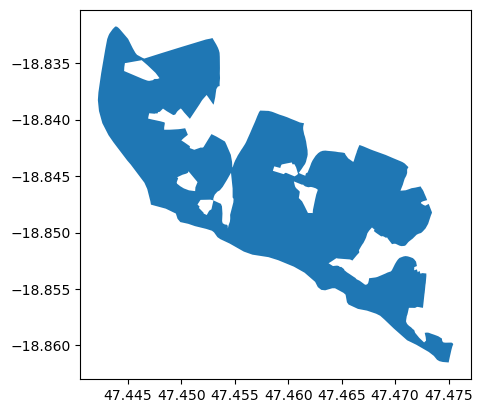

In [359]:
target = block_summary.loc[
    block_summary.validation_polygons_intersecting == 87, "block_id"
].iloc[0]

all_cities.iloc[[target]].plot()

# Validation polygon-based units of analysis

In [360]:


def area_weight_blocks_to_validation(
    all_cities: gpd.GeoDataFrame,
    validation_set: gpd.GeoDataFrame,
    label_col: str = "Label",
    equal_area_epsg: int = 6933,   # World Cylindrical Equal Area
    min_block_inclusion: float = 0.30,  # at least 30% of the block must lie in the validation polygon
):
    # ---- pick numeric metric columns from all_cities ----
    metric_cols = [
        c for c in all_cities.columns
        if c not in ["geometry",'city_name','block_area']
        and pd.api.types.is_numeric_dtype(all_cities[c])
    ]

    # ---- clean + project to equal-area for correct weights ----
    blocks = all_cities.copy()
    val = validation_set.copy()

    blocks = blocks[blocks.geometry.notnull()].copy()
    val = val[val.geometry.notnull()].copy()

    # fix invalid geoms (optional but often necessary)
    blocks["geometry"] = blocks.geometry.make_valid()
    val["geometry"] = val.geometry.make_valid()

    blocks = blocks.to_crs(epsg=equal_area_epsg)
    val = val.to_crs(epsg=equal_area_epsg)

    blocks["block_area"] = blocks.geometry.area

    # Guard against degenerate zero-area blocks
    blocks = blocks[blocks["block_area"] > 0].copy()

    # ensure stable id for validation polygons
    if "validation_id" not in val.columns:
        val = val.reset_index(drop=True)
        val["validation_id"] = val.index.astype("int64")

    # polygon area for weights
    val["val_area"] = val.geometry.area

    # ---- candidate matches (touching/intersects) ----
    pairs = gpd.sjoin(
        blocks[["geometry", "block_area", "city_name"] + metric_cols],
        val[["validation_id", label_col, "val_area", "geometry"]],
        predicate="intersects",
        how="inner",
    )

    # ---- intersection area + weights ----
    # (compute intersection only for matched pairs)
    left_geom = pairs.geometry
    val_geom = val.set_index("validation_id").geometry

    right_geom = gpd.GeoSeries(
        pairs["validation_id"].map(val_geom),
        index=pairs.index,
        crs=val.crs,
    )

    inter_area = pairs.geometry.intersection(right_geom).area


    pairs["inter_area"] = inter_area
    pairs = pairs[pairs["inter_area"] > 0].copy()  # drop pure touches (zero area)

    pairs["frac_block_in_val"] = pairs["inter_area"] / pairs["block_area"]
    pairs = pairs[pairs["frac_block_in_val"] >= min_block_inclusion].copy()

    pairs["w"] = pairs["inter_area"] / pairs["val_area"]

    # ---- weighted aggregation per validation polygon ----
    out = val[["validation_id", label_col, "geometry", "val_area"]].copy()

    # coverage diagnostics (how much of validation polygon is covered by blocks)
    cov = pairs.groupby("validation_id")["inter_area"].sum()
    out["covered_area"] = out["validation_id"].map(cov).fillna(0.0)
    out["coverage_frac"] = (out["covered_area"] / out["val_area"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    dominant_city = (
        pairs.groupby(["validation_id", "city_name"])["inter_area"]
            .sum()
            .reset_index()
            .sort_values(["validation_id", "inter_area"], ascending=[True, False])
            .drop_duplicates("validation_id")
            .set_index("validation_id")["city_name"]
    )

    out["city_name"] = out["validation_id"].map(dominant_city)


    # area-weighted means over the validation polygon area (Σ metric * w)
    for c in metric_cols:
        out[c] = pairs.groupby("validation_id").apply(lambda g: (g[c] * g["w"]).sum())

    return gpd.GeoDataFrame(out, geometry="geometry", crs=val.crs).to_crs(epsg=4326)


In [361]:
agg_to_validation = area_weight_blocks_to_validation(all_cities, validation_set, label_col="Label")
agg_to_validation['label_category'] = agg_to_validation['Label'].apply(lambda x: x[:2])
agg_to_validation['label_category'] = agg_to_validation['label_category'].astype(int) 

'''
subdivisions_dict = {
    11: 'Subdivision',
    13: 'Hybrid',
    14: 'Irregular Settlement',
    20: 'Non Residential',
    10: 'Open Area'
}
'''

subdivisions_dict = {
    1: 'Non Residential',
    2: 'Formal Subdivision',
    3: 'Formal Subdivision',
    4: 'Formal Subdivision',
    5: 'Informal Subdivision',
    6: 'Informal Subdivision',
    7: 'Informal Subdivision',
    8: 'Hybrid Subdivision',
    9: 'Hybrid Subdivision',
    10: 'Hybrid Subdivision',
    11: 'Irregular Settlement',
    12: 'Irregular Settlement',
    13: 'Irregular Settlement',
    14: 'Open Area'
}

saturation_dict = {
    1: np.nan,
    2: 'Early',
    3: 'Densifying',
    4: 'Saturated',
    5: 'Early',
    6: 'Densifying',
    7: 'Saturated',
    8: 'Early',
    9: 'Densifying',
    10: 'Saturated',
    11: 'Early',
    12: 'Densifying',
    13: 'Saturated',
    14: np.nan
}

agg_to_validation['label_cat_subdivision_irregular'] = agg_to_validation['label_category'].apply(lambda x: subdivisions_dict[int(x)])



agg_to_validation['built_vs_open'] = agg_to_validation['label_category'].apply(lambda x: 'built_up' if x<14 else 'open_space')


mapping_residential = {1: 'non-residential'}
mapping_residential.update({i: 'residential' for i in range(2, 14)})

agg_to_validation['residential'] = (
    agg_to_validation['label_category']
    .map(mapping_residential)
)

mapping_subdivisions = {}
mapping_subdivisions.update({i: 'subdivision' for i in range(2, 11)})
mapping_subdivisions.update({i: 'irregular_settlement' for i in range(11, 14)})

agg_to_validation['subdivisions_settlements'] = (
    agg_to_validation['label_category']
    .map(mapping_subdivisions)
)


mapping_formality = {}
mapping_formality.update({i: 'formal_subdivisions' for i in range(2, 5)})
mapping_formality.update({i: 'informal_subdivisions' for i in range(5, 8)})

agg_to_validation['formal_informal_subdivisions'] = (
    agg_to_validation['label_category']
    .map(mapping_formality)
)

/var/folders/nn/3mdkp6sx1n3d955f3wqgdbb00000gn/T/ipykernel_82334/709034662.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[c] = pairs.groupby("validation_id").apply(lambda g: (g[c] * g["w"]).sum())
/var/folders/nn/3mdkp6sx1n3d955f3wqgdbb00000gn/T/ipykernel_82334/709034662.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out[c] = pairs.groupby("validation_id").apply(lambda g: (g[c] * g["w"]).sum())
/var/f

In [362]:
### blocks_labeled

In [363]:
len(agg_to_validation)

38961

In [364]:
agg_to_validation[['built_vs_open', 'residential', 'subdivisions_settlements', 'formal_informal_subdivisions']].describe()

,built_vs_open,residential,subdivisions_settlements,formal_informal_subdivisions
count,38961,30120,17713,7177
unique,2,2,2,2
top,built_up,residential,subdivision,informal_subdivisions
freq,30120,17713,11790,3651


In [365]:
agg_to_validation.columns

Index(['validation_id', 'Label', 'geometry', 'val_area', 'covered_area',
       'coverage_frac', 'city_name', 'max_radius', 'block_area_km2',
       'built_area', 'n_buildings', 'index', 'total_len_m', 'road_length',
       'has_roads', 'n_intersections', 'intersections_3plus',
       'intersections_4way', 'has_intersections', 'm3_raw', 'm3_std', 'm4_raw',
       'm4_std', 'm5_raw', 'm5_std', 'm10_raw', 'm10_std', 'm11_raw',
       'm11_std', 'm12_raw', 'm12_std', 'sum_distance', 'n_closer_20m',
       'has_buildings', 'average_distance_nearest_building', 'm1_raw',
       'm1_std', 'm2_raw', 'm2_std', 'm6_raw', 'm6_std', 'm7_raw', 'm7_std',
       'm8_raw', 'm8_std', 'm9_raw', 'm9_std', 'k_on_network_street_length',
       'k_off_network_street_length', 'k_nearest_external_street',
       'k_building_count', 'k_complexity_raw', 'm9_n_intersections',
       'k_complexity_std', 'm1_final', 'm2_final', 'm3_final', 'm4_final',
       'm5_final', 'm6_final', 'm7_final', 'm8_final', 'm9_fina

In [366]:
validation_set.Land_Use.value_counts()

# irregular [3262, 1463, 1198]: total 5923
# subdivisions  [738, 1803, 1110, 1770, 1080, 676, 918, 1619, 2076]: total 11790


np.sum([3262, 1463, 1198])


np.int64(5923)

In [367]:
len(blocks_labeled)

65875

In [368]:
agg_to_validation.subdivisions_settlements.value_counts(normalize=True)

subdivisions_settlements
subdivision             0.665613
irregular_settlement    0.334387
Name: proportion, dtype: float64

In [369]:
blocks_labeled.subdivisions_settlements.value_counts(normalize=True)

subdivisions_settlements
subdivision             0.913037
irregular_settlement    0.086963
Name: proportion, dtype: float64

In [370]:
len(agg_to_validation)

38961

In [371]:
from scipy import stats

stats.ttest_ind(agg_to_validation[agg_to_validation['subdivisions_settlements']=='subdivision']['k_complexity_raw'].dropna(),
                agg_to_validation[agg_to_validation['subdivisions_settlements']=='irregular_settlement']['k_complexity_raw'].dropna())

TtestResult(statistic=np.float64(-19.4066133031588), pvalue=np.float64(1.9838960059672256e-82), df=np.float64(10311.0))

In [372]:
agg_to_validation.groupby(['built_vs_open'])[['m10_raw']].describe().transpose()

built_vs_open      built_up   open_space
m10_raw count  13349.000000  1618.000000
        mean    1506.884421   632.028150
        std     1427.603118   702.563628
        min        1.376832     5.130462
        25%      545.370320   197.905429
        50%     1113.796865   429.819508
        75%     1995.146092   816.572321
        max    15137.905996  7967.275107

In [373]:
all_cities.city_name.unique()

array(['Kpalime__Togo', 'Garoua__Cameroon', 'Cape_Town__South_Africa',
       'Addis_Ababa__Ethiopia', 'Maxixe__Mozambique', 'Asmara__Eritrea',
       'Libreville__Gabon', 'Bo__Sierra_Leone', 'Conakry__Guinea',
       'Bunia__Democratic_Republic_of_the_Congo', 'Whydah__Benin',
       'Kampala__Uganda', 'Fomboni__Comoros', 'Freetown__Sierra_Leone',
       'Niamey__Niger', 'Waku_Kungo__Angola', 'Bata__Equatorial_Guinea',
       'Minna__Nigeria', 'Antananarivo__Madagascar', 'Jimma__Ethiopia',
       'Monrovia__Liberia', 'Cotonou__Benin', 'Worcester__South_Africa',
       'Timbuktu__Mali', 'Dar_es_Salaam__Tanzania',
       'Belo_Horizonte__Brazil', 'Chimoio__Mozambique',
       'Serrekunda__Gambia', 'Tahoua__Niger', 'Manzini__Swaziland',
       'Kigali__Rwanda', 'Ndola__Zambia', 'Magaria__Niger',
       'Koidu_Town__Sierra_Leone', 'Harare__Zimbabwe',
       'Kinshasa__Democratic_Republic_of_the_Congo_Republic_of_Congo',
       'Maputo__Mozambique', 'Ouagadougou__Burkina_Faso',
       'Fran

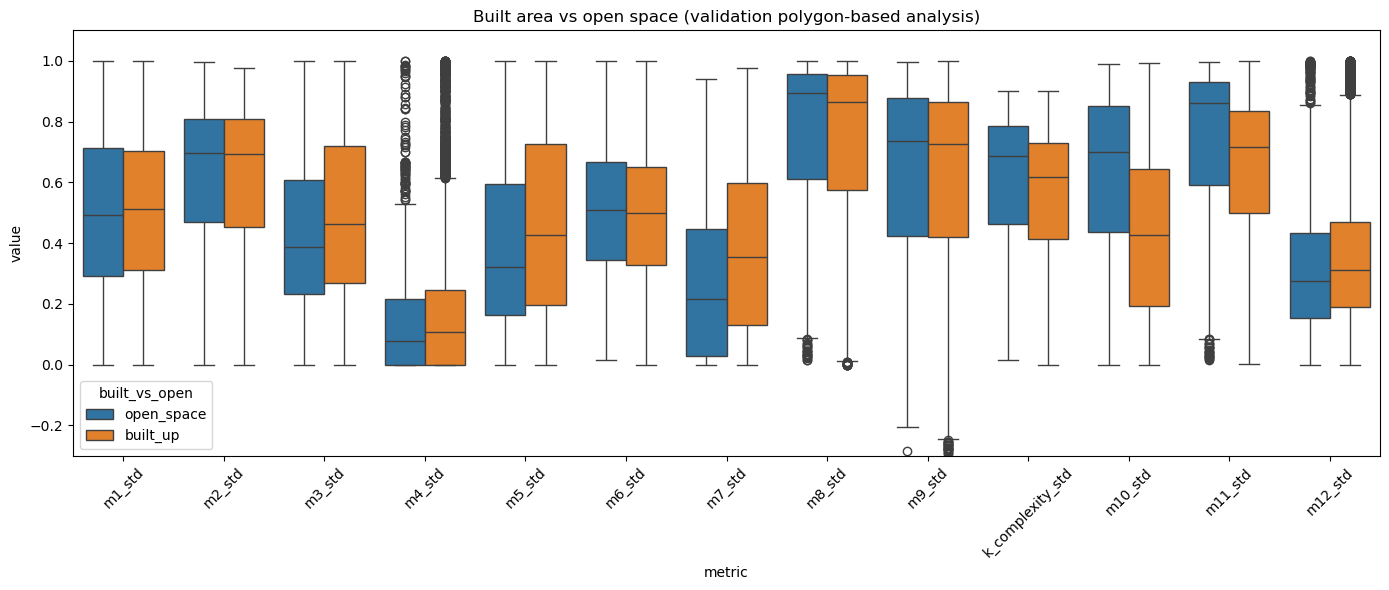

In [374]:
import seaborn as sns
import matplotlib.pyplot as plt


long_df = agg_to_validation.melt(
    id_vars='built_vs_open',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df,
    x='metric',
    y='value',
    hue='built_vs_open'
)

plt.xticks(rotation=45)
plt.ylim([-0.3,1.1])
plt.title('Built area vs open space (validation polygon-based analysis)')
plt.tight_layout()
plt.show()

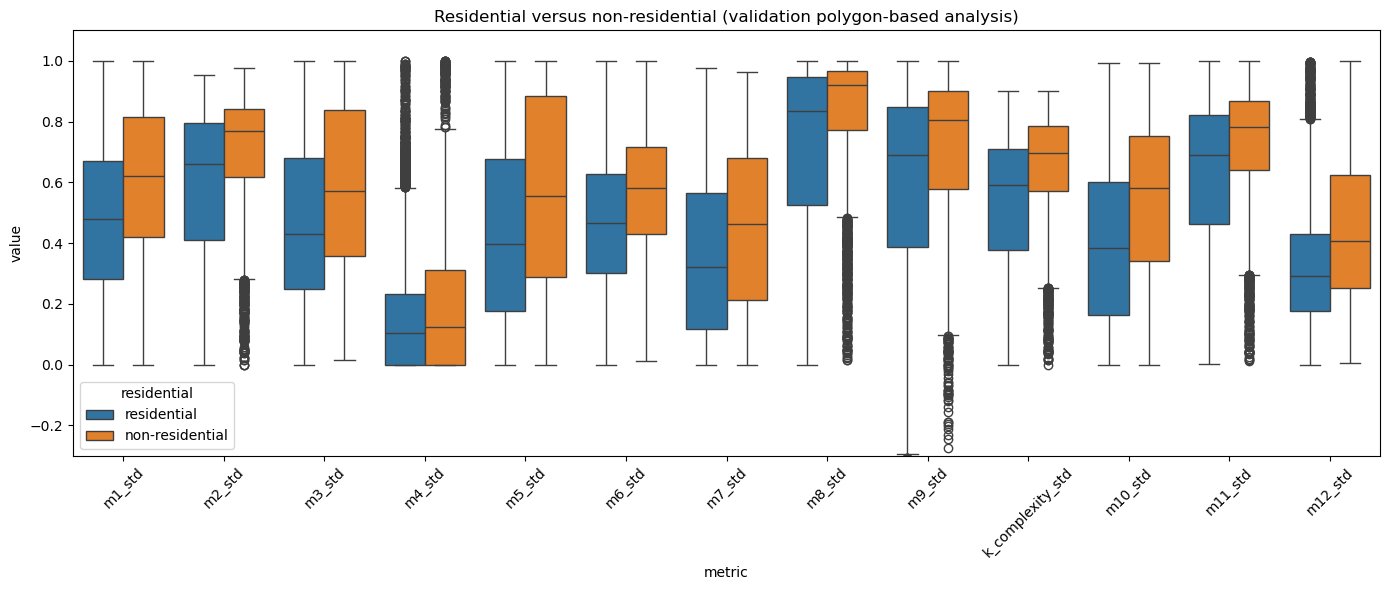

In [375]:

long_df = agg_to_validation.melt(
    id_vars='residential',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df,
    x='metric',
    y='value',
    hue='residential'
)

plt.xticks(rotation=45)
plt.title('Residential versus non-residential (validation polygon-based analysis)')
plt.ylim([-0.3,1.1])
plt.tight_layout()
plt.show()

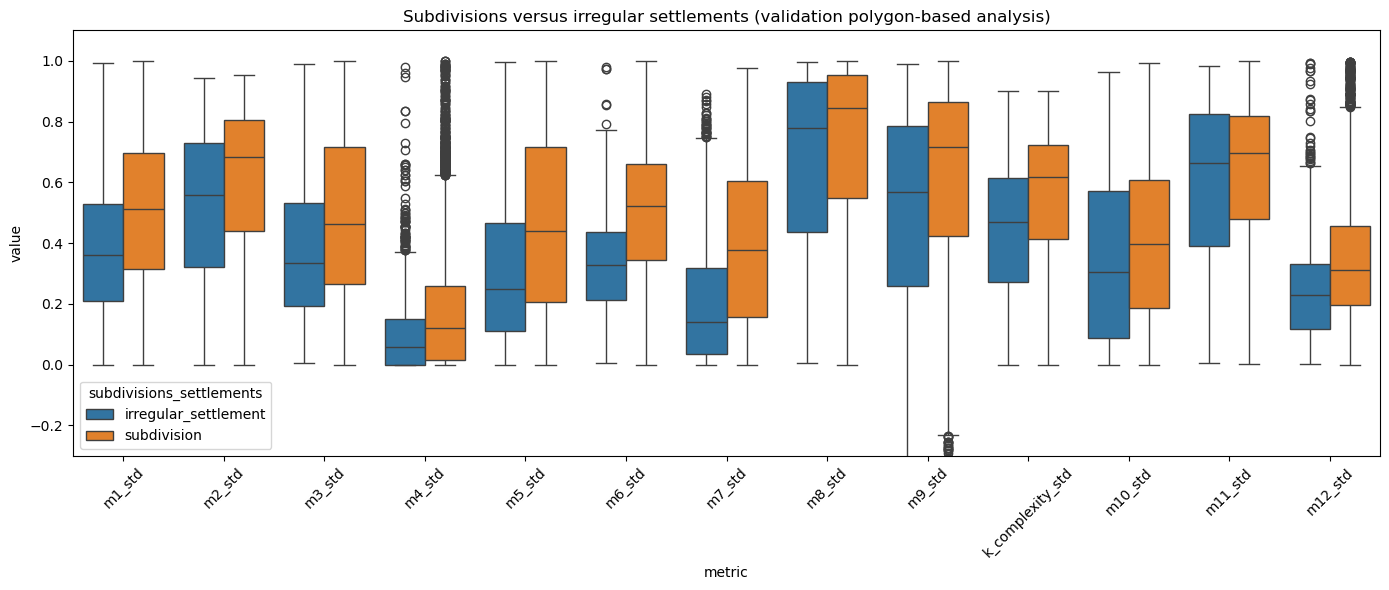

In [376]:

long_df = agg_to_validation.melt(
    id_vars='subdivisions_settlements',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df,
    x='metric',
    y='value',
    hue='subdivisions_settlements'
)

plt.xticks(rotation=45)
plt.title('Subdivisions versus irregular settlements (validation polygon-based analysis)')
plt.ylim([-0.3,1.1])
plt.tight_layout()
plt.show()

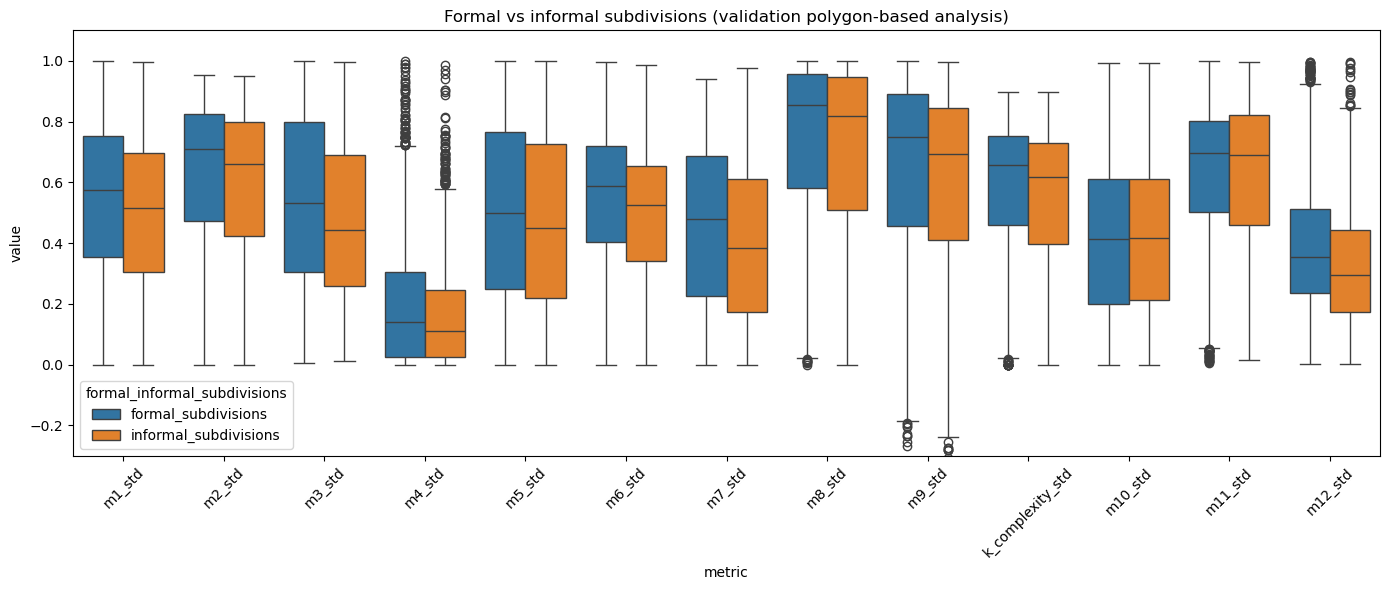

In [377]:

long_df = agg_to_validation.melt(
    id_vars='formal_informal_subdivisions',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df,
    x='metric',
    y='value',
    hue='formal_informal_subdivisions'
)

plt.xticks(rotation=45)
plt.title('Formal vs informal subdivisions (validation polygon-based analysis)')
plt.ylim([-0.3,1.1])
plt.tight_layout()
plt.show()

In [378]:
agg_to_validation.groupby("Label")[['m1_std', 'm2_std', 'm3_std',
                                           'm4_std','m5_std', 'm6_std','m7_std','m8_std','m9_std',
                                            'm10_std','m11_std','m12_std']].mean()


#'on_network_street_length', 'off_network_street_length', 'nearest_external_street', 'building_count', 'building_layers', 'k_complexity', 
# 'optimal_point', 'max_radius', 'n_buildings', 'sum_distance', 'n_closer_20m', 'has_buildings', 'average_distance_nearest_building', 
# 'm1_raw', 'm1_std', 'm2_raw', 'm2_std', 'block_area', 'block_area_km2', 'built_area', 'index', 'total_len_m', 'road_length', 'has_roads', 
# 'n_intersections', 'intersections_3plus', 'intersections_4way', 'has_intersections', 'm3_raw', 'm3_std', 'm4_raw', 'm4_std', 'm5_raw', 'm5_std', 
# 'm10_raw', 'm10_std', 'm11_raw', 'm11_std', 'm12_raw', 'm12_std', 'm6_raw', 'm6_std', 'm7_raw', 'm7_std', 'm8_raw', 'm8_std', 'm9_raw', 'm9_std'

,m1_std,m2_std,m3_std,m4_std,m5_std,m6_std,m7_std,m8_std,m9_std,m10_std,m11_std,m12_std
Label,,,,,,,,,,,,
1,0.605712,0.700008,0.581356,0.193918,0.561735,0.567880,0.441312,0.825368,0.638706,0.535684,0.722738,0.448190
10,0.551178,0.665625,0.576196,0.192027,0.526224,0.478086,0.425362,0.785681,0.635610,0.245304,0.624882,0.317528
11,0.274103,0.417135,0.255058,0.087606,0.184012,0.319693,0.100230,0.624381,0.476364,0.525534,0.621324,0.214466
12,0.362099,0.503195,0.353328,0.097456,0.285625,0.318151,0.177836,0.649789,0.471023,0.419633,0.609654,0.249592
13,0.443455,0.574963,0.457199,0.099217,0.400912,0.337844,0.271848,0.702060,0.513662,0.182431,0.573380,0.241820
14,0.501691,0.622958,0.437837,0.141486,0.394195,0.507057,0.268654,0.759204,0.587790,0.628047,0.737060,0.324737
2,0.358366,0.440881,0.293133,0.124223,0.291702,0.412175,0.223006,0.560687,0.490027,0.494698,0.550427,0.268474
3,0.496637,0.595770,0.482551,0.194904,0.455670,0.528796,0.403647,0.724948,0.594903,0.504370,0.655865,0.369821
4,0.622966,0.695051,0.633963,0.212894,0.579347,0.593743,0.536954,0.798722,0.672187,0.337815,0.639946,0.411848


In [379]:
agg_to_validation.groupby("Label")[['m1_raw','m2_raw','m3_raw', 'm4_raw', 'm5_raw', 'm6_raw', 'm7_raw', 'm8_raw', 'm9_raw',
                                            'm10_raw', 'm11_raw', 'm12_raw']].mean()

,m1_raw,m2_raw,m3_raw,m4_raw,m5_raw,m6_raw,m7_raw,m8_raw,m9_raw,m10_raw,m11_raw,m12_raw
Label,,,,,,,,,,,,
1,0.605712,14.391212,55.785950,0.193918,291.107605,0.567880,103.722230,0.823888,18.343886,1296.638676,0.121034,104.931259
10,0.551178,14.004729,52.926181,0.192027,248.775142,0.478086,97.358555,0.784295,15.165374,2712.115945,0.180790,65.398783
11,0.274103,23.857096,21.298195,0.087606,66.602126,0.319693,179.131067,0.622993,15.863435,515.601617,0.031301,42.957185
12,0.362099,17.610205,30.660831,0.097456,117.649190,0.318151,141.941741,0.648161,18.712880,1066.454688,0.069592,50.576409
13,0.443455,15.498340,41.676909,0.099217,186.056021,0.337844,119.510912,0.701194,19.463405,2778.778218,0.156566,52.055858
14,0.501691,16.125069,38.285873,0.141486,164.472020,0.507057,133.958847,0.758109,17.546728,632.028150,0.046390,68.581010
2,0.358366,14.430904,25.680800,0.124223,128.491874,0.412175,110.943018,0.557851,8.041056,357.634134,0.030306,58.531373
3,0.496637,14.997706,43.200356,0.194904,217.484730,0.528796,94.563812,0.721592,13.305325,964.029446,0.087670,77.182775
4,0.622966,12.537518,60.480023,0.212894,297.300114,0.593743,78.681268,0.794530,13.222109,2141.840612,0.180238,88.438956


## Block-based units of analysis 

In [380]:
import geopandas as gpd
import numpy as np

def label_blocks_from_validation(
    blocks: gpd.GeoDataFrame,
    validation: gpd.GeoDataFrame,
    label_col: str = "Label",
    equal_area_epsg: int = 6933,
    min_frac_block_in_val: float = 0.30,   # optional: require ≥30% of block inside the chosen polygon
):
    # copy + clean
    b = blocks[blocks.geometry.notna()].copy()
    v = validation[validation.geometry.notna()].copy()

    b["geometry"] = b.geometry.make_valid()
    v["geometry"] = v.geometry.make_valid()

    b = b.to_crs(epsg=equal_area_epsg)
    v = v.to_crs(epsg=equal_area_epsg)

    # stable ids
    b = b.reset_index(drop=True)
    b["block_id"] = b.index.astype("int64")

    v = v.reset_index(drop=True)
    v["validation_id"] = v.index.astype("int64")

    b["block_area"] = b.geometry.area
    v["val_area"] = v.geometry.area

    # candidate overlaps
    pairs = gpd.sjoin(
        b[["block_id", "geometry", "block_area"]],
        v[["validation_id", label_col, "val_area", "geometry"]],
        predicate="intersects",
        how="inner",
    ).drop(columns=["index_right"], errors="ignore")

    # intersection area
    v_geom = v.set_index("validation_id").geometry
    right_geom = gpd.GeoSeries(pairs["validation_id"].map(v_geom), index=pairs.index, crs=v.crs)
    pairs["inter_area"] = pairs.geometry.intersection(right_geom).area
    pairs = pairs[pairs["inter_area"] > 0].copy()

    pairs["frac_block_in_val"] = pairs["inter_area"] / pairs["block_area"]
    pairs = pairs[pairs["frac_block_in_val"] >= min_frac_block_in_val].copy()

    # For each block, how many validation polygons does it match (after threshold)?
    nmatch = pairs.groupby("block_id")["validation_id"].nunique()

    # Keep only blocks that match exactly one validation polygon
    keep_ids = nmatch[nmatch == 1].index

    pairs1 = pairs[pairs["block_id"].isin(keep_ids)].copy()

    # If multiple rows remain for a kept block (e.g., same validation polygon via multipart),
    # keep the largest intersection just for cleanliness
    pairs1 = (pairs1.sort_values(["block_id", "inter_area"], ascending=[True, False])
                   .drop_duplicates("block_id"))

    # attach label back to blocks
    out = b.merge(
        pairs1[["block_id", "validation_id", label_col, "frac_block_in_val", "inter_area"]],
        on="block_id",
        how="inner",
    )

    return out.to_crs(epsg=4326)

blocks_labeled = label_blocks_from_validation(all_cities, validation_set, label_col="Label", min_frac_block_in_val=0.9)

blocks_labeled

,geometry,optimal_point,max_radius,block_area,block_area_km2,built_area,n_buildings,index,total_len_m,road_length,...,m9_final,m10_final,m11_final,m12_final,k_complexity_final,block_id,validation_id,Label,frac_block_in_val,inter_area
0,"POLYGON ((0.6386 6.89492, 0.63846 6.89511, 0.6...",POINT (239105.17152490304 762850.2244279353),31.891415,7522.616415,0.007529,1133.824029,16,145954.0,747.427714,0.747428,...,4.895964e-01,0.888889,0.468741,0.885451,0.354320,36,36966,1,0.947138,7124.955220
1,"POLYGON ((0.6389 6.89649, 0.63907 6.89731, 0.6...",POINT (239130.0062161964 763020.0632930456),30.538813,4737.412534,0.004742,454.992774,8,124508.0,607.408669,0.607409,...,9.790438e-01,0.888889,0.578202,0.927008,0.284370,41,2249,6,0.999782,4736.381124
2,"POLYGON ((0.64816 6.90297, 0.64786 6.90301, 0....",POINT (240098.64382109485 763754.683658826),28.872978,6334.057790,0.006340,1587.749048,24,147734.0,704.375276,0.704375,...,9.790438e-01,0.888889,0.053566,0.809490,0.330781,47,30652,10,1.000000,6334.057790
3,"POLYGON ((0.64774 6.90302, 0.64786 6.90301, 0....",POINT (240076.57602053476 763603.4367615433),28.327590,5101.159218,0.005106,1085.842071,15,152739.0,594.509436,0.594509,...,1.480297e-16,0.888889,0.265514,0.838223,0.361947,48,30652,10,0.954091,4866.970844
4,"POLYGON ((0.64807 6.90209, 0.64808 6.90223, 0....",POINT (240244.85250576434 763577.4170175227),54.927410,20549.105924,0.020567,4015.277927,66,213320.0,1236.476241,1.236476,...,9.729461e-01,0.777778,0.197744,0.851495,0.304188,49,30652,10,0.947925,19479.010475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60437,"POLYGON ((11.92015 -4.70155, 11.92056 -4.70193...",POINT (824005.4617204639 9479532.708856408),76.480204,29067.869475,0.029120,3346.149076,47,NaN,768.314545,0.768315,...,9.802562e-01,0.888889,0.596500,0.912593,0.355973,890084,36243,6,0.950287,27622.831702
60438,"POLYGON ((11.923 -4.70422, 11.92344 -4.70461, ...",POINT (824309.7457574637 9479305.713849606),32.330961,22516.748451,0.022557,1757.453631,32,NaN,853.257459,0.853257,...,9.928955e-01,0.888889,0.645348,0.940736,0.274602,890085,32448,5,0.921995,20760.332391
60439,"POLYGON ((11.92009 -4.70336, 11.92049 -4.70372...",POINT (823873.3870779717 9479251.289225286),64.702744,54609.605854,0.054708,2785.469147,50,NaN,1140.063664,1.140064,...,9.921491e-01,0.888889,0.771513,0.961270,0.278547,890086,36243,6,1.000000,54609.605854
60440,"POLYGON ((11.92087 -4.70408, 11.92049 -4.70372...",POINT (824129.8654030166 9479474.837871728),31.065702,9148.464333,0.009165,1394.332118,17,NaN,424.266470,0.424266,...,9.916291e-01,0.888889,0.536277,0.884273,0.410098,890087,36243,6,0.964136,8820.364252


In [381]:
blocks_labeled['label_category'] = blocks_labeled['Label'].apply(lambda x: x[:2])
blocks_labeled['label_category'] = blocks_labeled['label_category'].astype(int) 

'''
subdivisions_dict = {
    11: 'Subdivision',
    13: 'Hybrid',
    14: 'Irregular Settlement',
    20: 'Non Residential',
    10: 'Open Area'
}
'''

subdivisions_dict = {
    1: 'Non Residential',
    2: 'Formal Subdivision',
    3: 'Formal Subdivision',
    4: 'Formal Subdivision',
    5: 'Informal Subdivision',
    6: 'Informal Subdivision',
    7: 'Informal Subdivision',
    8: 'Hybrid Subdivision',
    9: 'Hybrid Subdivision',
    10: 'Hybrid Subdivision',
    11: 'Irregular Settlement',
    12: 'Irregular Settlement',
    13: 'Irregular Settlement',
    14: 'Open Area'
}

saturation_dict = {
    1: np.nan,
    2: 'Early',
    3: 'Densifying',
    4: 'Saturated',
    5: 'Early',
    6: 'Densifying',
    7: 'Saturated',
    8: 'Early',
    9: 'Densifying',
    10: 'Saturated',
    11: 'Early',
    12: 'Densifying',
    13: 'Saturated',
    14: np.nan
}

blocks_labeled['label_cat_subdivision_irregular'] = blocks_labeled['label_category'].apply(lambda x: subdivisions_dict[int(x)])



blocks_labeled['built_vs_open'] = blocks_labeled['label_category'].apply(lambda x: 'built_up' if x<14 else 'open_space')


mapping_residential = {1: 'non-residential'}
mapping_residential.update({i: 'residential' for i in range(2, 14)})

blocks_labeled['residential'] = (
    blocks_labeled['label_category']
    .map(mapping_residential)
)

mapping_subdivisions = {}
mapping_subdivisions.update({i: 'subdivision' for i in range(2, 11)})
mapping_subdivisions.update({i: 'irregular_settlement' for i in range(11, 14)})

blocks_labeled['subdivisions_settlements'] = (
    blocks_labeled['label_category']
    .map(mapping_subdivisions)
)


mapping_formality = {}
mapping_formality.update({i: 'formal_subdivisions' for i in range(2, 5)})
mapping_formality.update({i: 'informal_subdivisions' for i in range(5, 8)})

blocks_labeled['formal_informal_subdivisions'] = (
    blocks_labeled['label_category']
    .map(mapping_formality))

In [382]:
blocks_labeled[['built_vs_open',	'residential',	'subdivisions_settlements',	'formal_informal_subdivisions']].count()

built_vs_open                   60442
residential                     60249
subdivisions_settlements        58597
formal_informal_subdivisions    40464
dtype: int64

In [383]:
blocks_labeled.groupby(['subdivisions_settlements'])[['k_complexity_raw']].describe().transpose()

subdivisions_settlements  irregular_settlement   subdivision
k_complexity_raw count             5392.000000  53201.000000
                 mean                 2.500556      1.972106
                 std                  1.148418      0.759905
                 min                  1.000000      1.000000
                 25%                  2.000000      1.000000
                 50%                  2.000000      2.000000
                 75%                  3.000000      2.000000
                 max                 13.000000     10.000000

In [384]:
blocks_labeled.groupby(['subdivisions_settlements'])[['m1_raw','m2_raw','m3_raw','m4_raw','m5_raw']].describe().transpose()

subdivisions_settlements  irregular_settlement   subdivision
m1_raw count                       5392.000000  53205.000000
       mean                           0.780498      0.823375
       std                            0.215915      0.202810
       min                            0.000000      0.000000
       25%                            0.625000      0.700000
       50%                            0.827586      0.888889
       75%                            1.000000      1.000000
       max                            1.000000      1.000000
m2_raw count                       5392.000000  53205.000000
       mean                          13.470398     12.247489
       std                            8.327725      6.636813
       min                            0.000000      0.000000
       25%                            7.826411      7.908281
       50%                           11.788112     11.172861
       75%                           17.052246     15.177065
       max                          147.772182    121.394163
m3_raw count                       5392.000000  53205.000000
       mean                          96.712612     89.015685
       std                           58.007502     45.341034
       min                            0.000000      0.000000
       25%                           56.523020     54.406756
       50%                           83.572089     81.624070
       75%                          122.004791    112.580595
       max                         1073.000564    403.698909
m4_raw count                       5392.000000  53205.000000
       mean                           0.151423      0.312685
       std                            0.219205      0.332141
       min                            0.000000      0.000000
       25%                            0.000000      0.000000
       50%                            0.000000      0.250000
       75%                            0.250000      0.500000
       max                            1.000000      1.000000
m5_raw count                       5392.000000  53205.000000
       mean                         563.850610    524.163610
       std                          592.989840    478.105864
       min                            0.000000      0.000000
       25%                          191.504596    215.865562
       50%                          378.678832    390.479477
       75%                          734.134125    675.293345
       max                         5674.066098   6606.986877

In [385]:
blocks_labeled.groupby(['subdivisions_settlements'])[['m6_raw','m7_raw','m8_raw','m9_raw']].describe().transpose()

subdivisions_settlements  irregular_settlement   subdivision
m6_raw count                       5392.000000  53201.000000
       mean                           0.569649      0.748145
       std                            0.165465      0.154865
       min                            0.248729      0.251179
       25%                            0.443567      0.650078
       50%                            0.557201      0.760270
       75%                            0.671229      0.844117
       max                            1.000000      1.000000
m7_raw count                       5392.000000  53201.000000
       mean                          90.309977     72.060672
       std                           54.532810     36.556264
       min                           10.848815      7.039925
       25%                           54.139294     50.266906
       50%                           76.668718     63.027176
       75%                          110.352128     82.015953
       max                          560.664992    891.220179
m8_raw count                       5392.000000  53201.000000
       mean                           0.959204      0.977883
       std                            0.054600      0.055558
       min                            0.000000      0.000000
       25%                            0.947680      0.982639
       50%                            0.976725      0.998910
       75%                            0.990776      1.000000
       max                            1.000000      1.000000
m9_raw count                       5391.000000  53154.000000
       mean                          21.483379     11.934795
       std                           41.076155     31.976704
       min                            0.005318      0.000005
       25%                            7.983548      2.377727
       50%                           11.923552      5.834258
       75%                           17.627059     10.450504
       max                          270.000000    270.000000

In [386]:
stats.ttest_ind(blocks_labeled[blocks_labeled['subdivisions_settlements']=='subdivision']['k_complexity_raw'].dropna(),
                blocks_labeled[blocks_labeled['subdivisions_settlements']=='irregular_settlement']['k_complexity_raw'].dropna())

TtestResult(statistic=np.float64(-46.01613968745113), pvalue=np.float64(0.0), df=np.float64(58591.0))

In [387]:
blocks_labeled.groupby('built_vs_open')[metrics_std].median().transpose()

built_vs_open,built_up,open_space
m1_std,0.884615,1.000000
m2_std,0.887769,0.894597
m3_std,1.000000,0.788432
m4_std,0.200000,0.000000
m5_std,1.000000,0.776866
m6_std,0.750391,0.846471
m7_std,0.799262,0.644738
m8_std,0.998193,0.991662
m9_std,0.927069,0.899133
k_complexity_std,0.800000,0.900000


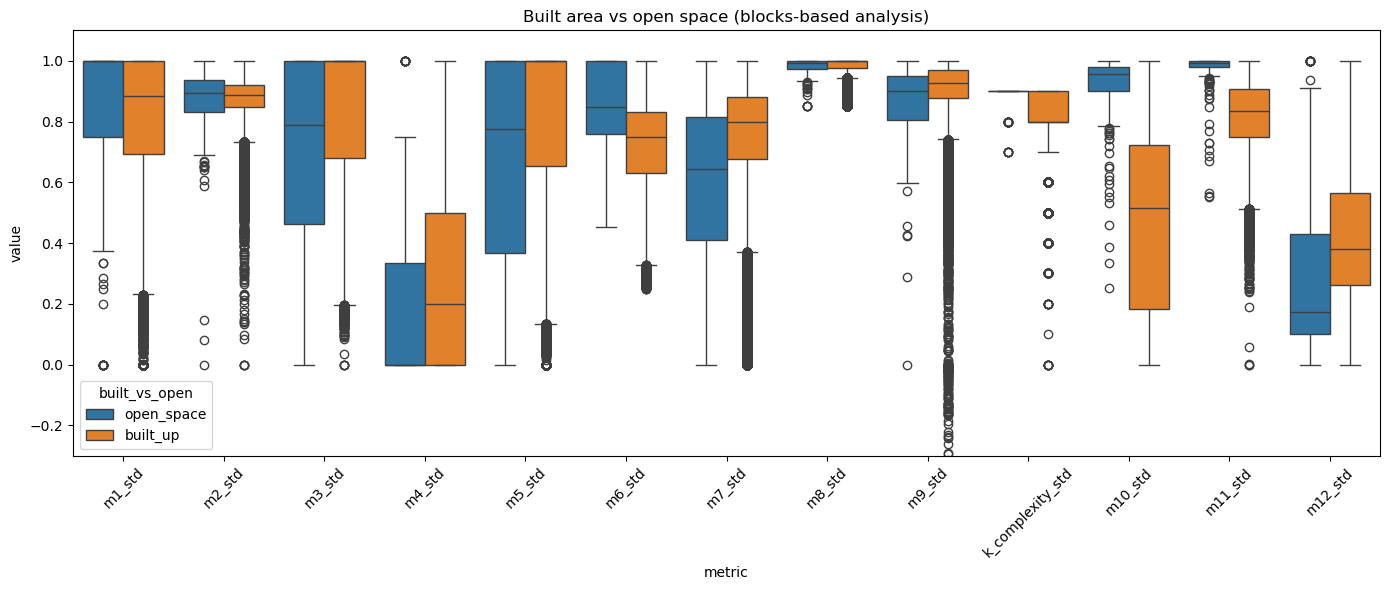

In [388]:
import seaborn as sns
import matplotlib.pyplot as plt


long_df_blocks = blocks_labeled.melt(
    id_vars='built_vs_open',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df_blocks,
    x='metric',
    y='value',
    hue='built_vs_open',
    hue_order=['open_space','built_up']
)

plt.xticks(rotation=45)
plt.ylim([-0.3,1.1])
plt.title('Built area vs open space (blocks-based analysis)')
plt.tight_layout()
plt.show()

In [389]:
all_cities.area.describe()

/var/folders/nn/3mdkp6sx1n3d955f3wqgdbb00000gn/T/ipykernel_82334/1266255166.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_cities.area.describe()


count    8.901150e+05
mean     3.478464e-06
std      2.596958e-05
min      5.706222e-08
25%      4.860389e-07
50%      8.823500e-07
75%      1.744844e-06
max      5.345285e-03
dtype: float64

In [390]:
long_df_blocks

,built_vs_open,metric,value
0,built_up,m1_std,0.937500
1,built_up,m1_std,1.000000
2,built_up,m1_std,0.916667
3,built_up,m1_std,1.000000
4,built_up,m1_std,0.590909
...,...,...,...
785741,built_up,m12_std,0.355973
785742,built_up,m12_std,0.274602
785743,built_up,m12_std,0.278547
785744,built_up,m12_std,0.410098


In [391]:
long_df

,formal_informal_subdivisions,metric,value
0,NaN,m1_std,0.796950
1,NaN,m1_std,NaN
2,NaN,m1_std,NaN
3,NaN,m1_std,NaN
4,NaN,m1_std,0.269942
...,...,...,...
506488,NaN,m12_std,NaN
506489,formal_subdivisions,m12_std,0.431724
506490,formal_subdivisions,m12_std,0.312489
506491,formal_subdivisions,m12_std,0.166067


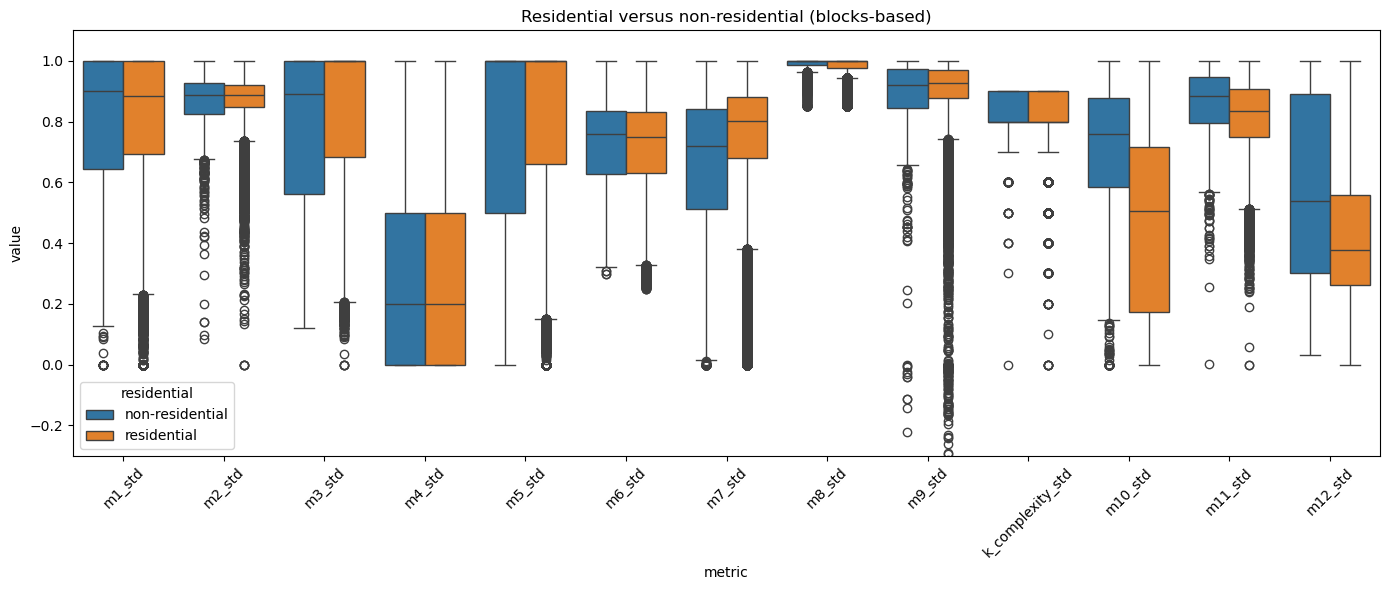

In [392]:

long_df_blocks = blocks_labeled.melt(
    id_vars='residential',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df_blocks,
    x='metric',
    y='value',
    hue='residential'
)

plt.xticks(rotation=45)
plt.title('Residential versus non-residential (blocks-based)')
plt.ylim([-0.3,1.1])
plt.tight_layout()
plt.show()

In [393]:
all_cities.to_crs("EPSG:6933").area.describe()

count    8.901150e+05
mean     4.116393e+04
std      3.069334e+05
min      6.990778e+02
25%      5.812149e+03
50%      1.047878e+04
75%      2.064701e+04
max      6.535545e+07
dtype: float64

In [394]:
blocks_labeled.area

/var/folders/nn/3mdkp6sx1n3d955f3wqgdbb00000gn/T/ipykernel_82334/2229594720.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_labeled.area


0        6.154780e-07
1        3.876022e-07
2        5.182423e-07
3        4.173677e-07
4        1.681290e-06
             ...     
60437    2.369263e-06
60438    1.835302e-06
60439    4.451134e-06
60440    7.456735e-07
60441    8.030375e-07
Length: 60442, dtype: float64

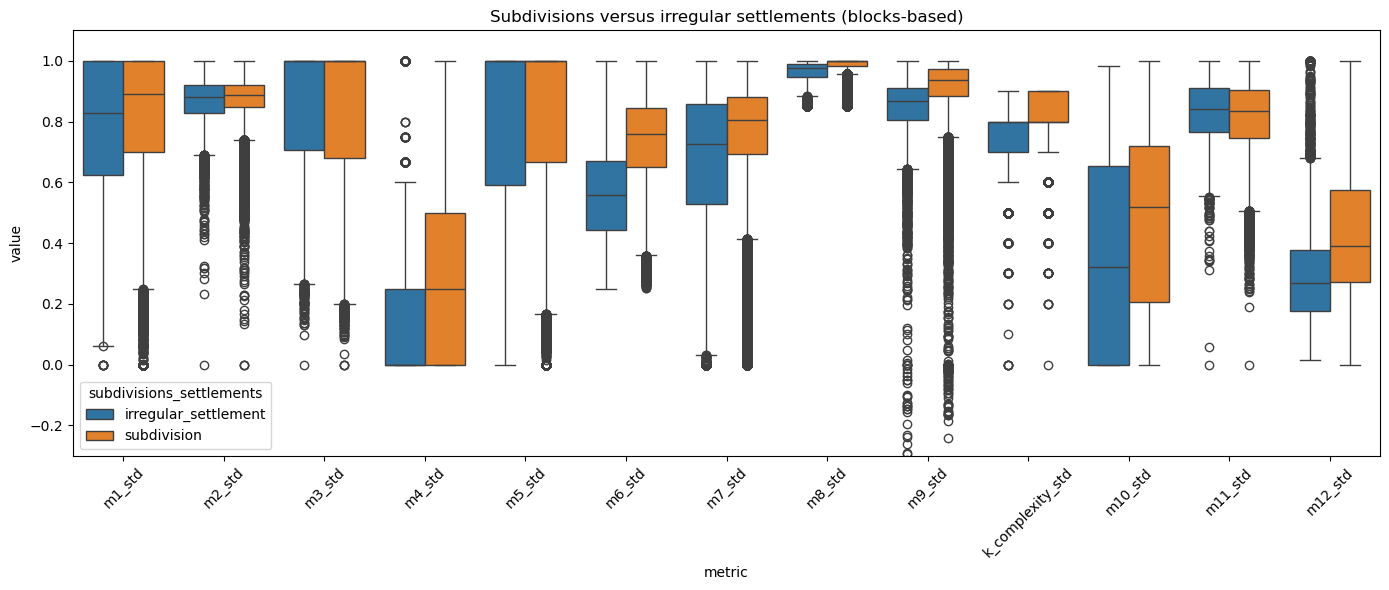

In [395]:

long_df_blocks = blocks_labeled.melt(
    id_vars='subdivisions_settlements',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df_blocks,
    x='metric',
    y='value',
    hue='subdivisions_settlements',
    hue_order=['irregular_settlement','subdivision']
)

plt.xticks(rotation=45)
plt.title('Subdivisions versus irregular settlements (blocks-based)')
plt.ylim([-0.3,1.1])
plt.tight_layout()
plt.show()

In [396]:
table_medians = (
    blocks_labeled
    .groupby('subdivisions_settlements')[metrics_std]
    .median()
    .transpose()
)

table_medians

subdivisions_settlements,irregular_settlement,subdivision
m1_std,0.827586,0.888889
m2_std,0.882119,0.888271
m3_std,1.000000,1.000000
m4_std,0.000000,0.250000
m5_std,1.000000,1.000000
m6_std,0.557201,0.760270
m7_std,0.725478,0.805722
m8_std,0.976725,0.998910
m9_std,0.867516,0.935175
k_complexity_std,0.800000,0.800000


In [397]:
table_description = (
    blocks_labeled
    .groupby('subdivisions_settlements')['k_complexity_raw']
    .describe()
    .transpose()
)

table_description

subdivisions_settlements,irregular_settlement,subdivision
count,5392.000000,53201.000000
mean,2.500556,1.972106
std,1.148418,0.759905
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,2.000000
75%,3.000000,2.000000
max,13.000000,10.000000


In [398]:
table_means = (
    blocks_labeled
    .groupby('subdivisions_settlements')[metrics_std]
    .mean()
    .transpose()
)

table_means

subdivisions_settlements,irregular_settlement,subdivision
m1_std,0.780498,0.823375
m2_std,0.865385,0.877531
m3_std,0.843498,0.839156
m4_std,0.151423,0.312685
m5_std,0.789072,0.817727
m6_std,0.569649,0.748145
m7_std,0.659966,0.756000
m8_std,0.962530,0.981404
m9_std,0.761296,0.867391
k_complexity_std,0.750056,0.802789


In [399]:
blocks_labeled.groupby('formal_informal_subdivisions').describe()[['m8_raw','m8_std','m9_raw','m9_std']].transpose()

formal_informal_subdivisions  formal_subdivisions  informal_subdivisions
m8_raw count                         23334.000000           17126.000000
       mean                              0.976664               0.980766
       std                               0.064645               0.046718
       min                               0.000000               0.000000
       25%                               0.988998               0.984603
       50%                               0.999892               0.998310
       75%                               1.000000               0.999950
       max                               1.000000               1.000000
m8_std count                         23334.000000           17126.000000
       mean                              0.982012               0.982896
       std                               0.037492               0.032528
       min                               0.850000               0.850000
       25%                               0.988998               0.984603
       50%                               0.999892               0.998310
       75%                               1.000000               0.999950
       max                               1.000000               1.000000
m9_raw count                         23306.000000           17116.000000
       mean                              9.877244              11.972951
       std                              30.584743              30.000567
       min                               0.002236               0.000005
       25%                               1.549826               3.654867
       50%                               3.668374               6.913178
       75%                               8.334913              10.159699
       max                             270.000000             270.000000
m9_std count                         23306.000000           17116.000000
       mean                              0.890253               0.866967
       std                               0.339830               0.333340
       min                              -2.000000              -2.000000
       25%                               0.907390               0.887114
       50%                               0.959240               0.923187
       75%                               0.982780               0.959390
       max                               0.999975               1.000000

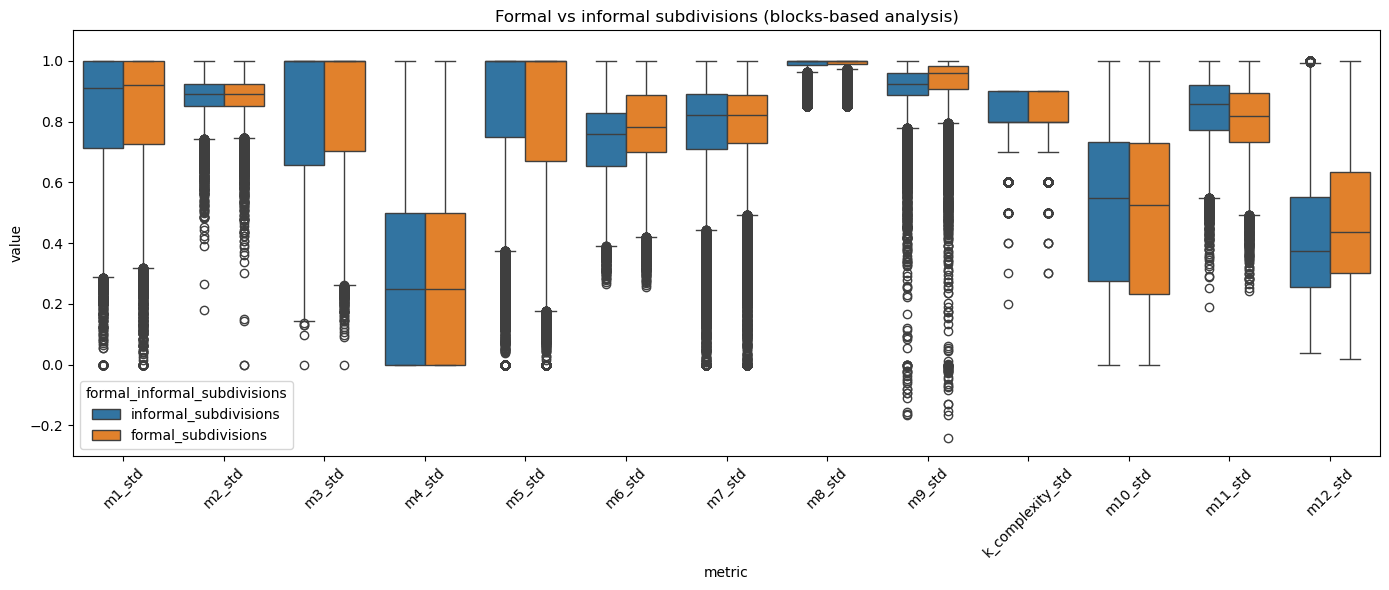

In [400]:

long_df_blocks = blocks_labeled.melt(
    id_vars='formal_informal_subdivisions',
    value_vars=metrics_std,
    var_name='metric',
    value_name='value'
)


plt.figure(figsize=(14,6))

sns.boxplot(
    data=long_df_blocks,
    x='metric',
    y='value',
    hue='formal_informal_subdivisions'
)

plt.xticks(rotation=45)
plt.title('Formal vs informal subdivisions (blocks-based analysis)')
plt.ylim([-0.3,1.1])
plt.tight_layout()
plt.show()

In [401]:
metrics_std

['m1_std',
 'm2_std',
 'm3_std',
 'm4_std',
 'm5_std',
 'm6_std',
 'm7_std',
 'm8_std',
 'm9_std',
 'k_complexity_std',
 'm10_std',
 'm11_std',
 'm12_std']

# CORRELATIONS

In [402]:


#all_cities['m8_final'] = (all_cities['m8_std'] - all_cities['m8_std'].min())/(all_cities['m8_std'].max() - all_cities['m8_std'].min())
all_cities[metrics_final].describe()

,m1_final,m2_final,m3_final,m4_final,m5_final,m6_final,m7_final,m8_final,m9_final,m10_final,m11_final,m12_final,k_complexity_final
count,890115.000000,890115.000000,890115.000000,890115.000000,890115.000000,889926.000000,889926.000000,889926.000000,888301.000000,889926.000000,890115.000000,890115.000000,8.901150e+05
mean,0.786188,0.859644,0.769802,0.266098,0.770971,0.586062,0.671064,0.839598,0.932596,0.847068,0.388696,0.823788,4.613413e-01
std,0.216088,0.101596,0.262030,0.307643,0.309255,0.231708,0.271819,0.252198,0.166210,0.114388,0.311923,0.102082,2.313996e-01
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.937225e-07
25%,0.656124,0.835587,0.553271,0.000000,0.548971,0.427740,0.574775,0.777477,0.947415,0.777778,0.049452,0.756517,2.885645e-01
50%,0.833333,0.880260,0.886376,0.200000,1.000000,0.603031,0.753792,0.971495,0.970431,0.888889,0.384030,0.828185,4.173443e-01
75%,1.000000,0.916154,1.000000,0.500000,1.000000,0.737504,0.863386,0.999618,0.986413,0.888889,0.650705,0.901969,5.889609e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.999894,1.000000,1.000000e+00


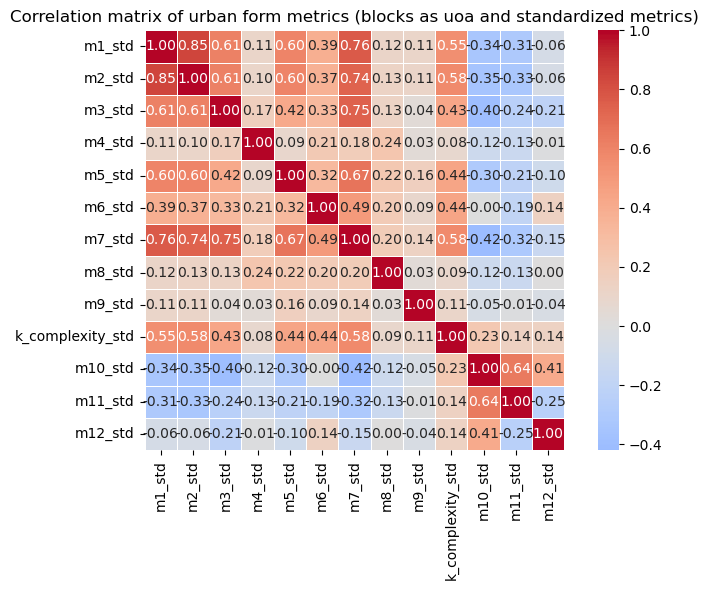

In [403]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd


X = all_cities[metrics_std].copy()


X = X.dropna()


corr = X.corr(method="pearson")
corr



plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation matrix of urban form metrics (blocks as uoa and standardized metrics)")
plt.tight_layout()
plt.show()


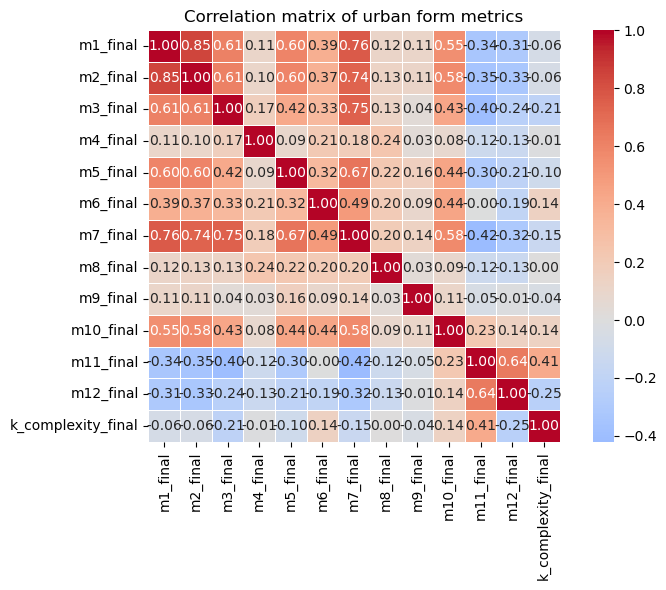

In [404]:

X = all_cities[metrics_final].copy()


X = X.dropna()


corr = X.corr(method="pearson")
corr



plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation matrix of urban form metrics")
plt.tight_layout()
plt.show()


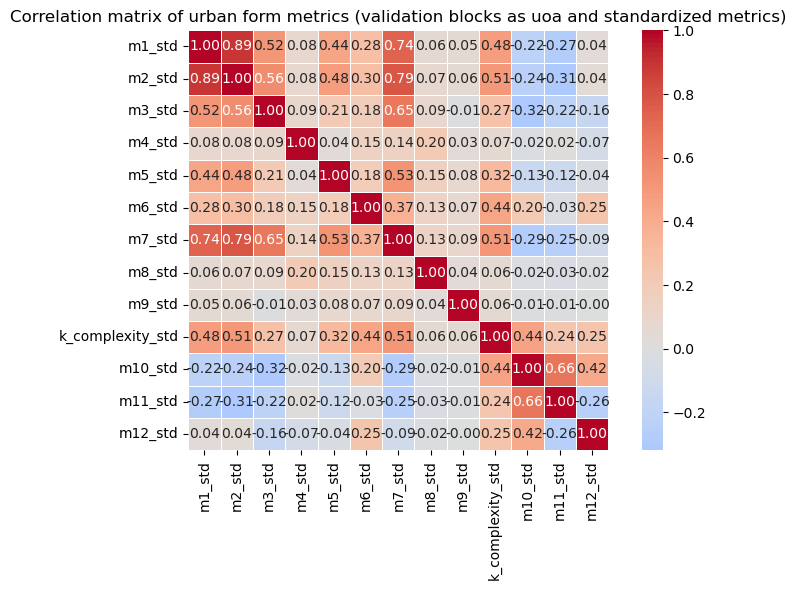

In [405]:
X = blocks_labeled[metrics_std].copy()


X = X.dropna()


corr = X.corr(method="pearson")
corr



plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation matrix of urban form metrics (validation blocks as uoa and standardized metrics)")
plt.tight_layout()
plt.show()

## PCA and factor analysis

In [406]:
import importlib
import pca_fa_pipeline
importlib.reload(pca_fa_pipeline)
from pca_fa_pipeline import *

  PART 1: PCA — Dimensionality Analysis
PCA on 888,301 observations, 13 features

Parallel analysis suggests retaining 4 components
(Kaiser criterion — eigenvalue > 1 — suggests 4)


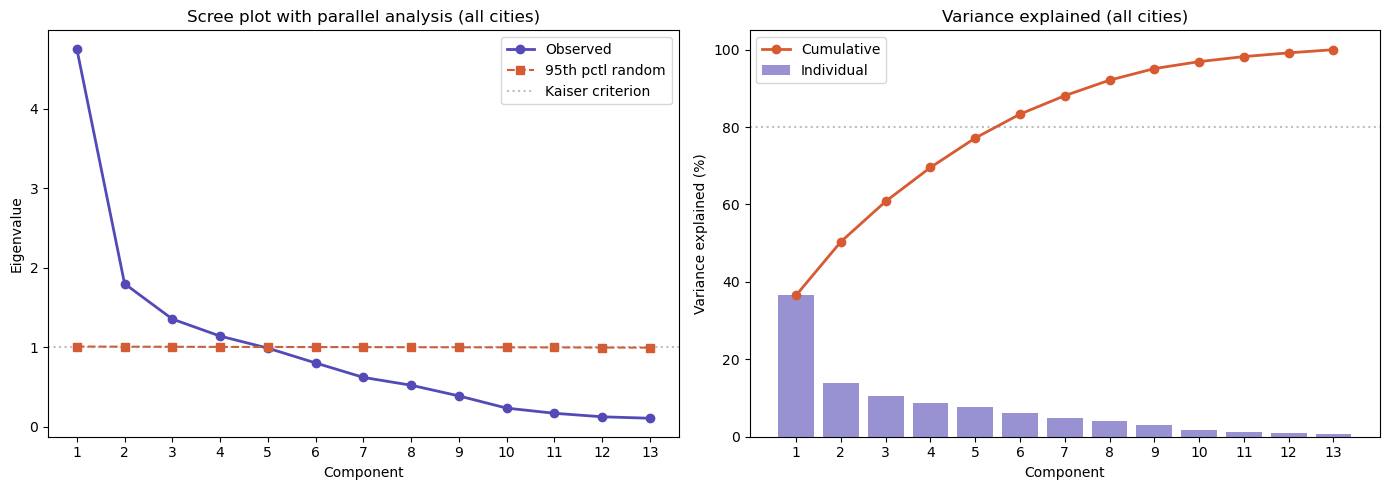

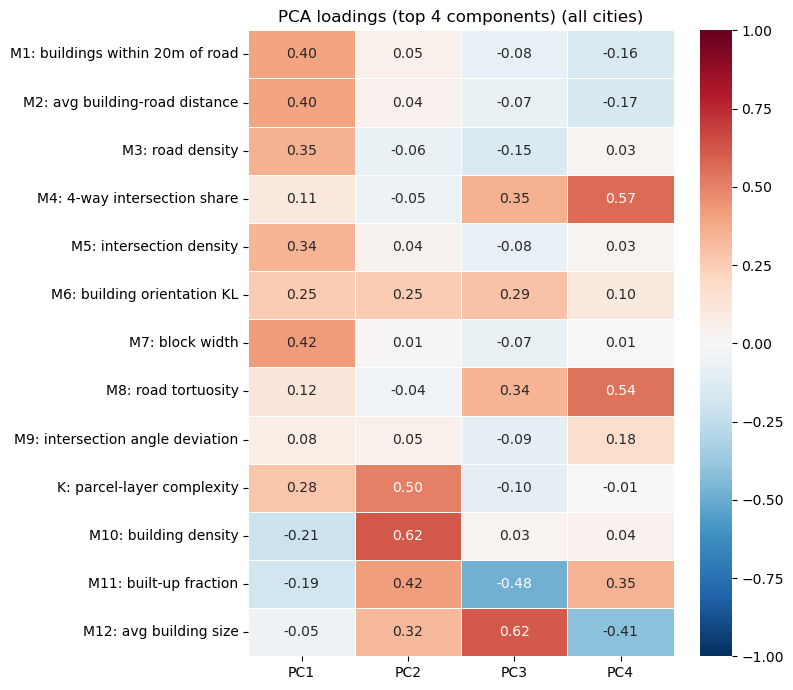


 Component  Eigenvalue  Var_Explained_%  Cumulative_%  Random_95th  Retain
      PC1    4.751616        36.550852     36.550852     1.008305    True
      PC2    1.798443        13.834165     50.385017     1.006488    True
      PC3    1.354075        10.415949     60.800966     1.005425    True
      PC4    1.139853         8.768090     69.569056     1.004000    True
      PC5    0.988362         7.602775     77.171831     1.003066   False
      PC6    0.802079         6.169830     83.341660     1.001879   False
      PC7    0.620324         4.771718     88.113378     1.000890   False
      PC8    0.522022         4.015551     92.128929     0.999998   False
      PC9    0.387682         2.982167     95.111096     0.999121   False
     PC10    0.234256         1.801966     96.913062     0.998206   False
     PC11    0.169298         1.302294     98.215356     0.997383   False
     PC12    0.125144         0.962643     99.177999     0.995967   False
     PC13    0.106860         0.8220

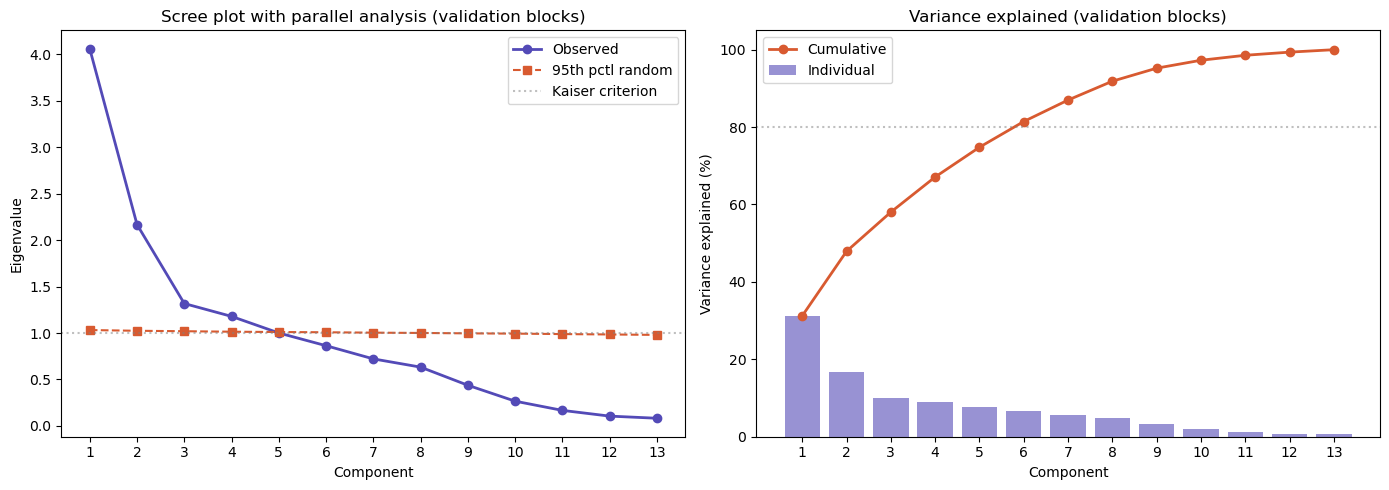

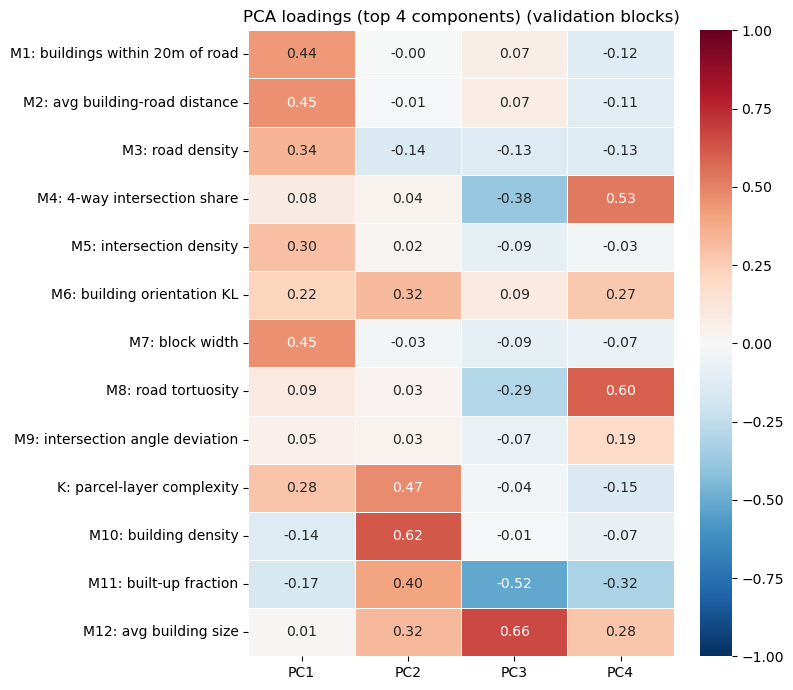


 Component  Eigenvalue  Var_Explained_%  Cumulative_%  Random_95th  Retain
      PC1    4.059716        31.228065     31.228065     1.031945    True
      PC2    2.167737        16.674625     47.902690     1.024046    True
      PC3    1.317425        10.133873     58.036564     1.019354    True
      PC4    1.178947         9.068673     67.105237     1.014011    True
      PC5    1.000432         7.695504     74.800741     1.010762   False
      PC6    0.863333         6.640916     81.441656     1.007957   False
      PC7    0.721415         5.549253     86.990909     1.003798   False
      PC8    0.632768         4.867365     91.858274     1.000593   False
      PC9    0.437504         3.365361     95.223636     0.996341   False
     PC10    0.266162         2.047364     97.270999     0.993295   False
     PC11    0.167009         1.284667     98.555667     0.988535   False
     PC12    0.105419         0.810900     99.366566     0.984396   False
     PC13    0.082348         0.6334

/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Communalities (higher = better captured by the factors):
        Variable                            Label  Communality  Uniqueness
          m1_std M1: buildings within 20m of road     0.837743    0.162257
          m2_std   M2: avg building-road distance     1.587472   -0.587472
          m3_std                 M3: road density     0.331940    0.668060
          m4_std     M4: 4-way intersection share     0.065328    0.934672
          m5_std         M5: intersection density     0.284934    0.715066
          m6_std      M6: building orientation KL     0.294724    0.705276
          m7_std                  M7: block width     0.609069    0.390931
          m8_std              M8: road tortuosity     0.046208    0.953792
          m9_std M9: intersection angle deviation     0.013505    0.986495
k_complexity_std       K: parcel-layer complexity     0.580217    0.419783
         m10_std            M10: building density     0.698306    0.301694
         m11_std           M11: built-up f

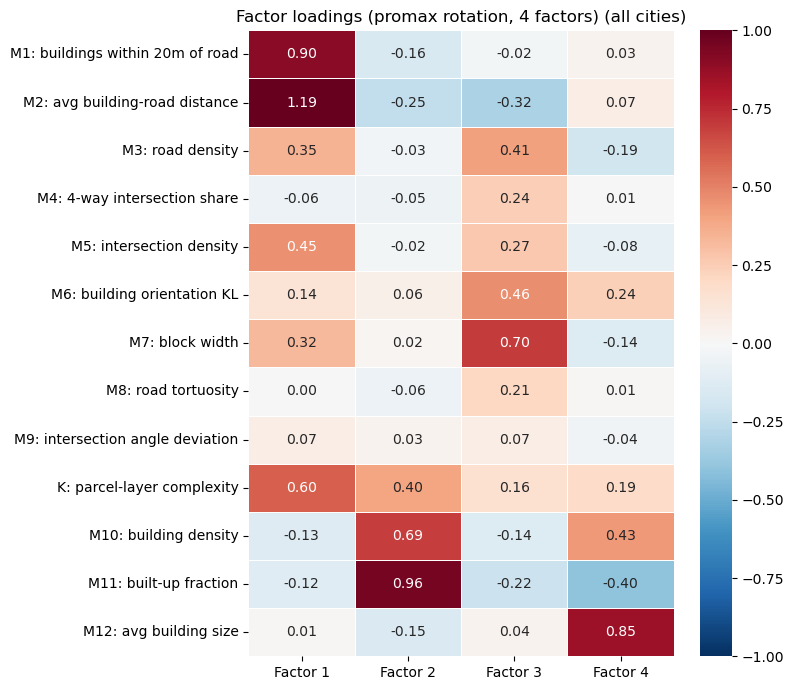


Factor correlations (promax):
          Factor 1  Factor 2  Factor 3  Factor 4
Factor 1     1.000     0.032     0.266    -0.145
Factor 2     0.032     1.000    -0.140     0.745
Factor 3     0.266    -0.140     1.000    -0.096
Factor 4    -0.145     0.745    -0.096     1.000


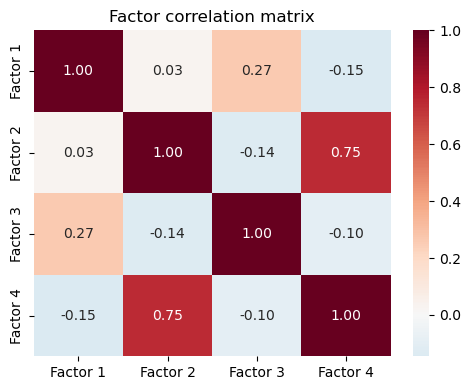


Factor assignments:
          Metric                            Label Dominant_Factor  Loading Cross_loading
          m1_std M1: buildings within 20m of road        Factor 1 0.900681            no
          m2_std   M2: avg building-road distance        Factor 1 1.191929           YES
          m5_std         M5: intersection density        Factor 1 0.454820            no
k_complexity_std       K: parcel-layer complexity        Factor 1 0.600644           YES
         m10_std            M10: building density        Factor 2 0.691831           YES
         m11_std           M11: built-up fraction        Factor 2 0.956494           YES
          m3_std                 M3: road density        Factor 3 0.413430           YES
          m4_std     M4: 4-way intersection share        Factor 3 0.243864            no
          m6_std      M6: building orientation KL        Factor 3 0.463310            no
          m7_std                  M7: block width        Factor 3 0.696727           YES


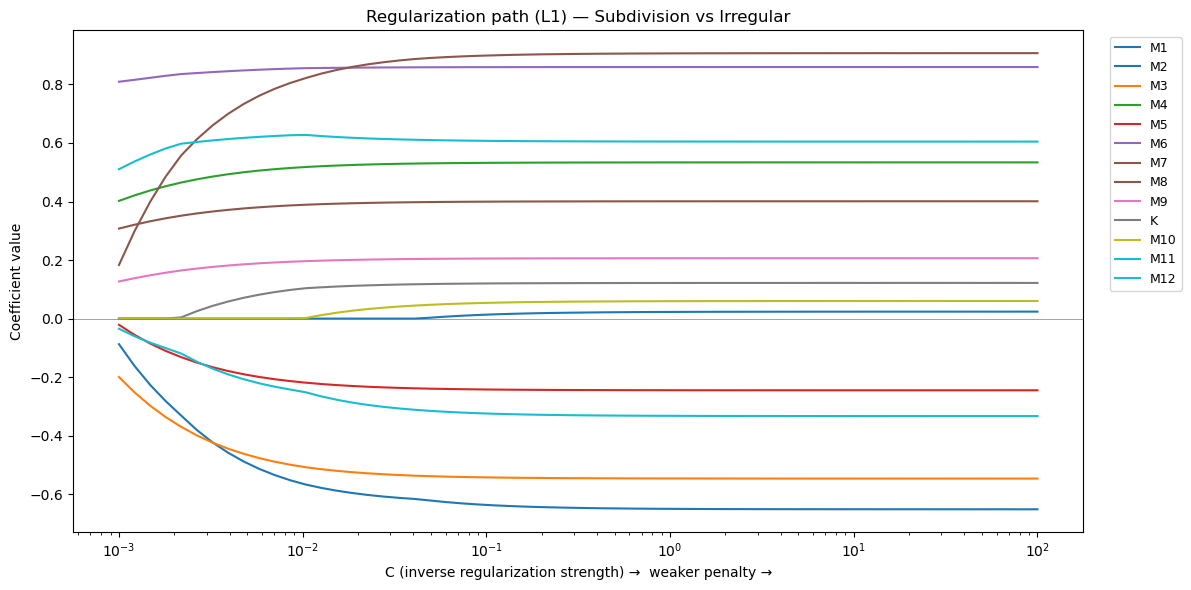


Feature entry order (first to enter = most robustly important):
          Metric                            Label  Entry_C  Rank
          m2_std   M2: avg building-road distance 0.001000     1
          m3_std                 M3: road density 0.001000     2
          m4_std     M4: 4-way intersection share 0.001000     3
          m5_std         M5: intersection density 0.001000     4
          m6_std      M6: building orientation KL 0.001000     5
          m7_std                  M7: block width 0.001000     6
          m8_std              M8: road tortuosity 0.001000     7
          m9_std M9: intersection angle deviation 0.001000     8
         m11_std           M11: built-up fraction 0.001000     9
         m12_std           M12: avg building size 0.001000    10
k_complexity_std       K: parcel-layer complexity 0.002183    11
         m10_std            M10: building density 0.010398    12
          m1_std M1: buildings within 20m of road 0.049535    13

  PART 4: Coefficient St

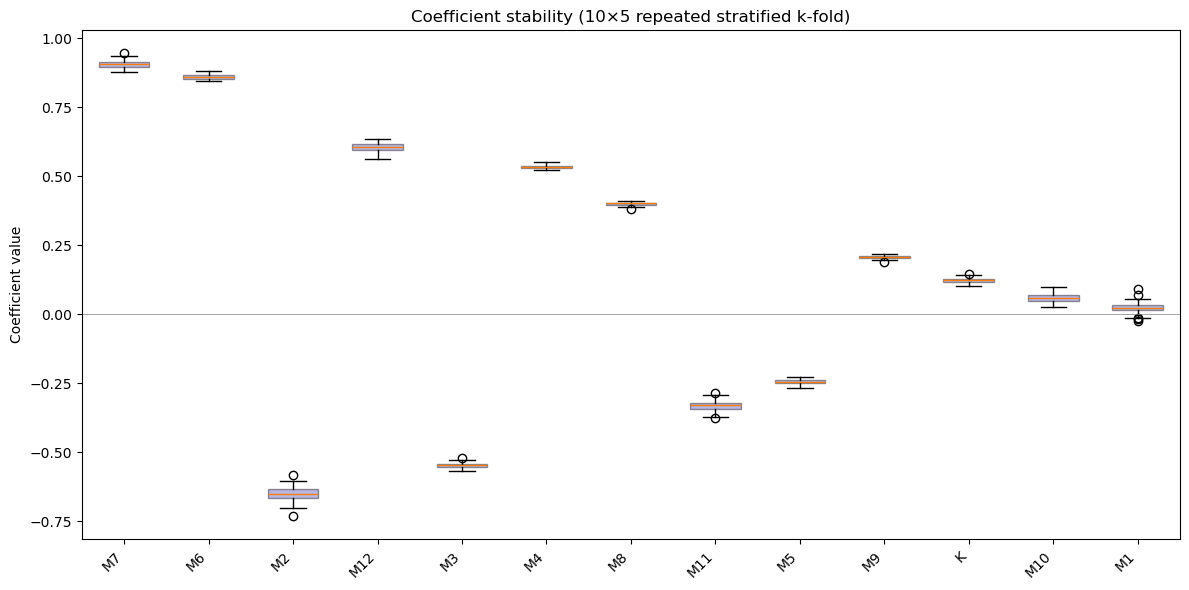


  PART 5: Calibrated Probability Cascade

--- Stage 1: Built vs Open Space ---


/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaco

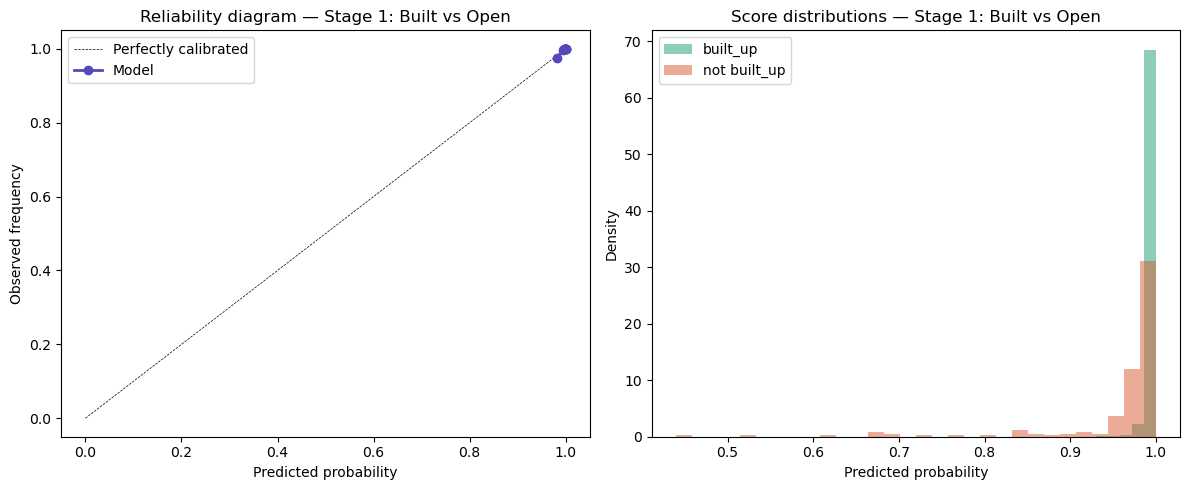


  Stage 1: Built vs Open
  ROC-AUC:     0.9150
  Brier score: 0.0030
  Classification report (at 0.5 threshold):
              precision    recall  f1-score   support

           0       1.00      0.01      0.01       193
           1       1.00      1.00      1.00     60245

    accuracy                           1.00     60438
   macro avg       1.00      0.50      0.50     60438
weighted avg       1.00      1.00      1.00     60438

  ECE (Expected Calibration Error): 0.0013
  (Lower = better calibrated. <0.05 is good, <0.02 is excellent)

--- Stage 2: Residential vs Non-residential ---


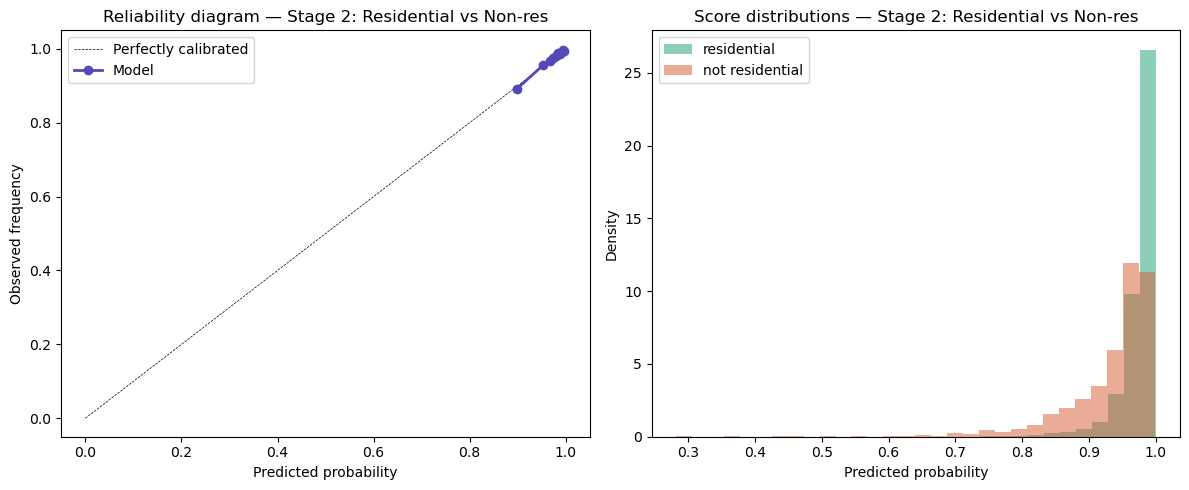


  Stage 2: Residential vs Non-res
  ROC-AUC:     0.7624
  Brier score: 0.0255
  Classification report (at 0.5 threshold):
              precision    recall  f1-score   support

           0       0.56      0.00      0.01      1646
           1       0.97      1.00      0.99     58545

    accuracy                           0.97     60191
   macro avg       0.76      0.50      0.50     60191
weighted avg       0.96      0.97      0.96     60191

  ECE (Expected Calibration Error): 0.0022
  (Lower = better calibrated. <0.05 is good, <0.02 is excellent)

--- Stage 3: Subdivision vs Irregular ---


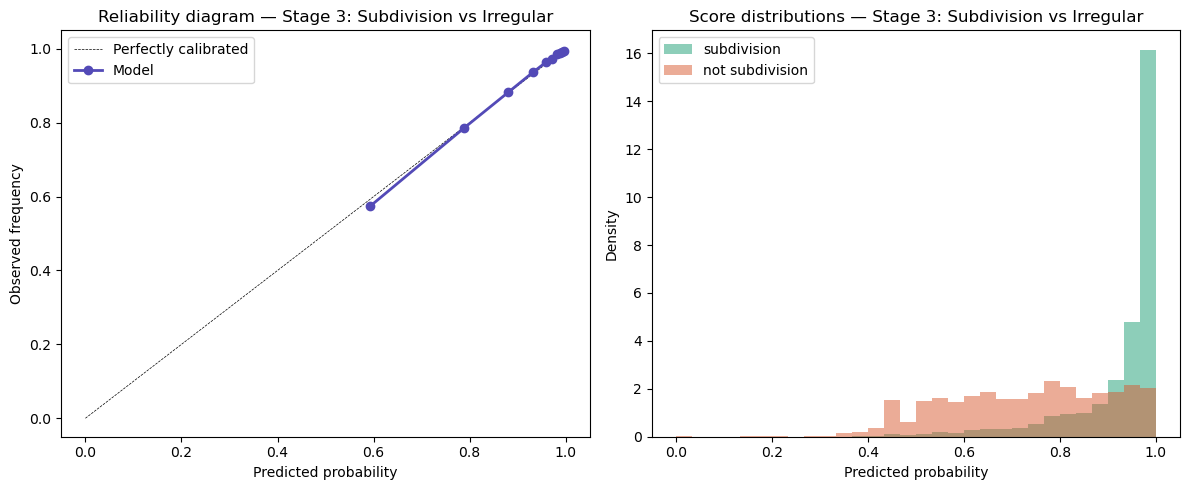


  Stage 3: Subdivision vs Irregular
  ROC-AUC:     0.8601
  Brier score: 0.0664
  Classification report (at 0.5 threshold):
              precision    recall  f1-score   support

           0       0.55      0.10      0.17      5391
           1       0.92      0.99      0.95     53154

    accuracy                           0.91     58545
   macro avg       0.73      0.55      0.56     58545
weighted avg       0.88      0.91      0.88     58545

  ECE (Expected Calibration Error): 0.0040
  (Lower = better calibrated. <0.05 is good, <0.02 is excellent)

--- Stage 4: Formal vs Informal Subdivisions ---


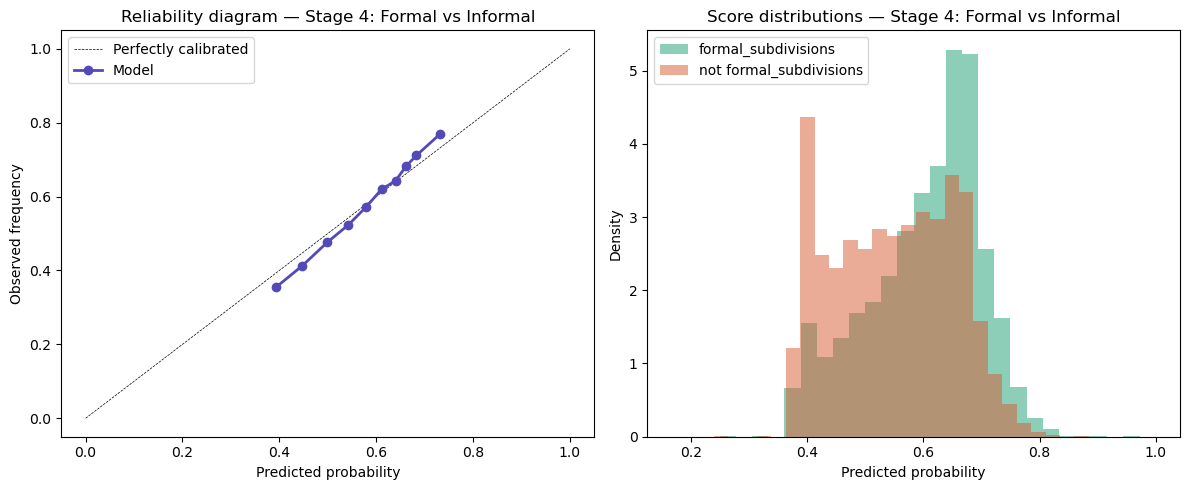


  Stage 4: Formal vs Informal
  ROC-AUC:     0.6499
  Brier score: 0.2286
  Classification report (at 0.5 threshold):
              precision    recall  f1-score   support

           0       0.60      0.36      0.45     17116
           1       0.64      0.82      0.72     23306

    accuracy                           0.63     40422
   macro avg       0.62      0.59      0.58     40422
weighted avg       0.62      0.63      0.60     40422

  ECE (Expected Calibration Error): 0.0221
  (Lower = better calibrated. <0.05 is good, <0.02 is excellent)

  SUMMARY & RECOMMENDATIONS

    PCA found 4 meaningful dimensions in your 13 metrics.
    Factor analysis reveals the latent constructs — check the loadings
    heatmap to name them (e.g., 'road network quality', 'building pattern').

    Key results for the regularity index:
    - Stage 3 ROC-AUC (calibrated): 0.8601
    - Stage 3 ECE (calibration error): 0.0040
    - Stage 3 Brier score: 0.0664

    Coefficient stability (from repeated k-

/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid 


Scored 890,115 blocks

Classification distribution:
classification
formal_subdivision      550691
informal_subdivision    301336
irregular_settlement     35160
unclassified              1814
non_residential           1114

Regularity index summary (residential built-up blocks only):
count    887187.000000
mean          0.883057
std           0.151605
min           0.040000
25%           0.826077
50%           0.958895
75%           0.988556
max           0.998726


In [407]:
# %%
from pca_fa_pipeline import *
results = run_full_pipeline(all_cities, blocks_labeled)
scored = score_all_blocks(all_cities, results)

Residential blocks: 58,597
  Subdivisions:         53,205
  Irregular settlements: 5,392

  All 13 metrics
  Features:           13
  ROC-AUC (repeated): 0.8612 ± 0.0089
  ROC-AUC (calib):    0.8601
  Brier score:        0.0664
  ECE:                0.0042

  Coefficients:
              M7: block width: +0.906 [+0.883, +0.935]
           M6: orientation KL: +0.859 [+0.845, +0.878]
       M2: avg bldg-road dist: -0.651 [-0.699, -0.605]
           M12: avg bldg size: +0.605 [+0.572, +0.633]
             M3: road density: -0.546 [-0.560, -0.527]
        M4: 4-way intxn share: +0.534 [+0.524, +0.551]
               M8: tortuosity: +0.401 [+0.389, +0.410]
          M11: built fraction: -0.333 [-0.371, -0.295]
            M5: intxn density: -0.245 [-0.265, -0.228]
          M9: angle deviation: +0.206 [+0.197, +0.216]
                K: complexity: +0.122 [+0.103, +0.142]
            M10: bldg density: +0.060 [+0.036, +0.092]
           M1: bldg near road: +0.023 [-0.016, +0.067]

  Regulari

/Users/sarangof/Documents/Identifying Land Subdivisions/identifyingLandSubdivisions/model_comparison.py:185: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(pp, pt, 'o-', color=color, linestyle=ls, linewidth=2,


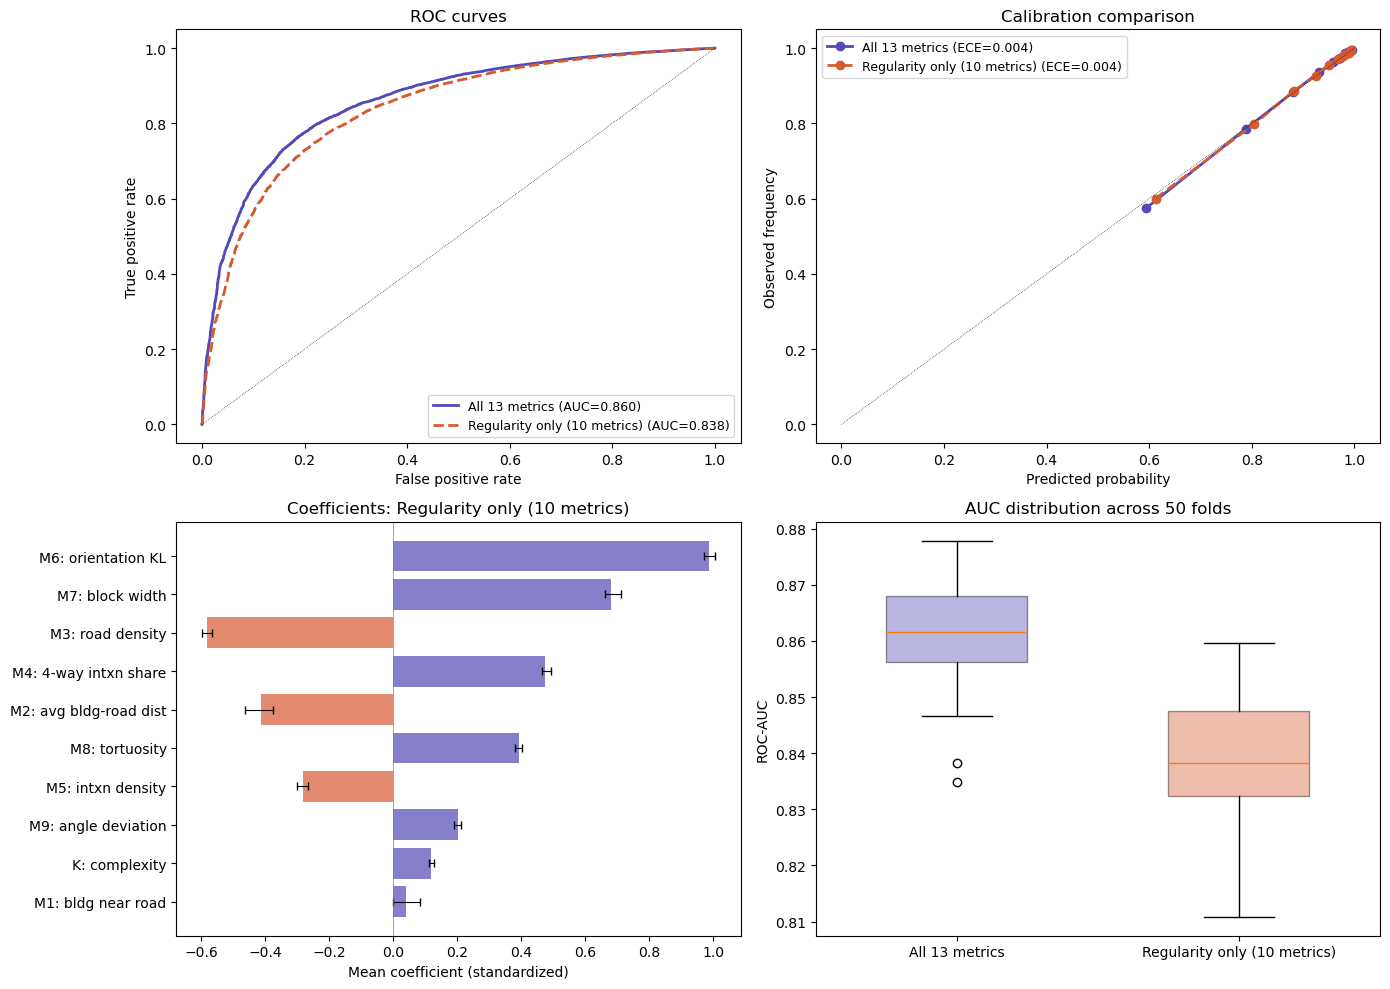


  MODEL COMPARISON SUMMARY
                       Model  N_features  AUC_mean  AUC_std  AUC_calibrated    Brier      ECE
              All 13 metrics          13  0.861247 0.008920        0.860111 0.066415 0.004171
Regularity only (10 metrics)          10  0.839111 0.010394        0.838158 0.068664 0.003725

  Paired AUC difference (A - B): +0.0221 ± 0.0044
  t-statistic: 35.77 (>2 = significant at p<0.05)


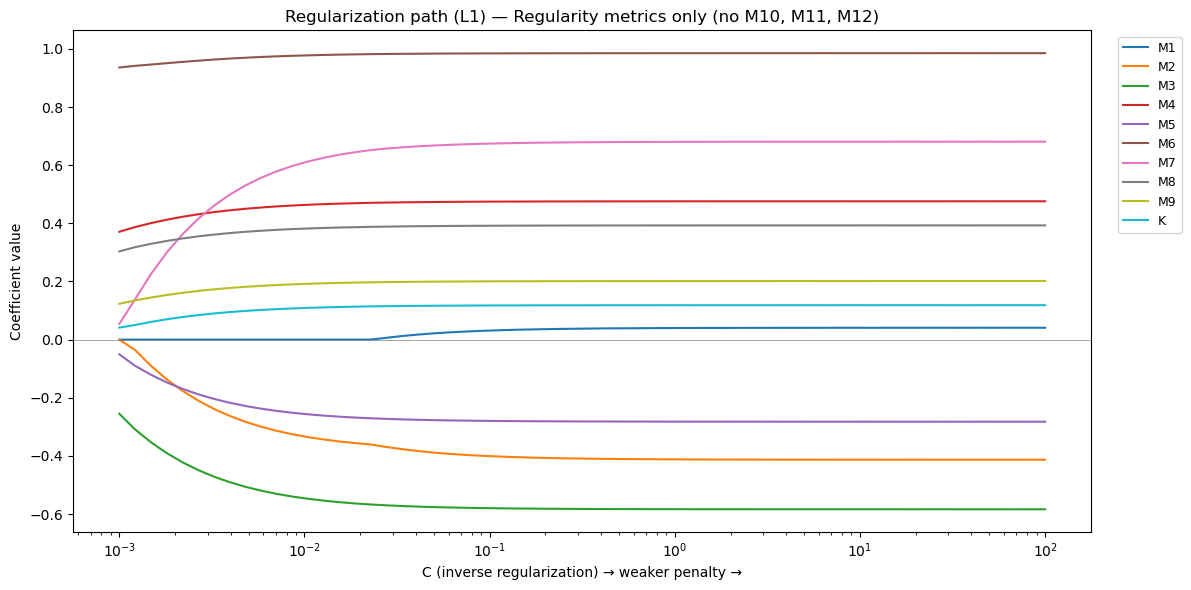


Feature entry order (regularity-only):
          Metric                  Label  Entry_C  Rank
          m3_std       M3: road density 0.001000     1
          m4_std  M4: 4-way intxn share 0.001000     2
          m5_std      M5: intxn density 0.001000     3
          m6_std     M6: orientation KL 0.001000     4
          m7_std        M7: block width 0.001000     5
          m8_std         M8: tortuosity 0.001000     6
          m9_std    M9: angle deviation 0.001000     7
k_complexity_std          K: complexity 0.001000     8
          m2_std M2: avg bldg-road dist 0.001215     9
          m1_std     M1: bldg near road 0.022695    10


In [408]:
from model_comparison import run_comparison
result_a, result_b, summary = run_comparison(blocks_labeled)

In [409]:
# Mean coefficients from 50 repeated k-fold fits
result_b['coef_summary'][['Metric', 'Mean_Coef', 'CI_lower', 'CI_upper']]

,Metric,Mean_Coef,CI_lower,CI_upper
5,m6_std,0.985313,0.971432,1.005255
6,m7_std,0.680488,0.660542,0.710555
2,m3_std,-0.583333,-0.597677,-0.566110
3,m4_std,0.475769,0.465041,0.491890
1,m2_std,-0.412557,-0.462600,-0.374335
7,m8_std,0.392806,0.380354,0.401380
4,m5_std,-0.282159,-0.301849,-0.266315
8,m9_std,0.201360,0.190823,0.210932
9,k_complexity_std,0.118415,0.110599,0.128555
0,m1_std,0.040322,-0.000428,0.083556


In [410]:
print(result_b['coef_summary'][['Metric','Mean_Coef','CI_lower','CI_upper']].to_string())

             Metric  Mean_Coef  CI_lower  CI_upper
5            m6_std   0.985313  0.971432  1.005255
6            m7_std   0.680488  0.660542  0.710555
2            m3_std  -0.583333 -0.597677 -0.566110
3            m4_std   0.475769  0.465041  0.491890
1            m2_std  -0.412557 -0.462600 -0.374335
7            m8_std   0.392806  0.380354  0.401380
4            m5_std  -0.282159 -0.301849 -0.266315
8            m9_std   0.201360  0.190823  0.210932
9  k_complexity_std   0.118415  0.110599  0.128555
0            m1_std   0.040322 -0.000428  0.083556


# Logistic Models

## Open space

In [411]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

In [412]:
def run_logistic_model(
    df,
    feature_cols,
    target_col,
    positive_class,
    test_size=0.2,
    random_state=42
):
    # --- 1. Drop NA ---
    data = df[feature_cols + [target_col]].dropna().copy()

    # --- 2. Binary target ---
    y = (data[target_col] == positive_class).astype(int)
    X = data[feature_cols]

    # --- 3. Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # --- 4. Model ---
    model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        max_iter=5000,
        class_weight='balanced'
    )

    model.fit(X_train, y_train)

    # --- 5. Predictions ---
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # --- 6. Metrics ---
    results = {}

    results['classification_report'] = classification_report(y_test, y_pred, output_dict=True)
    results['confusion_matrix'] = confusion_matrix(y_test, y_pred)
    results['roc_auc'] = roc_auc_score(y_test, y_prob)
    results['brier_score'] = brier_score_loss(y_test, y_prob)

    # --- 7. Calibration ---
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    results['calibration'] = (prob_true, prob_pred)

    # --- 8. Coefficients ---
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': model.coef_[0]
    }).sort_values(by='coefficient', key=np.abs, ascending=False)

    results['coefficients'] = coef_df
    results['intercept'] = model.intercept_[0]
    results['model'] = model

    return results, y_test, y_prob

## Built vs open space

In [413]:
blocks_labeled[(blocks_labeled['built_vs_open']=='built_up')&(blocks_labeled['n_buildings']==0)]

,geometry,optimal_point,max_radius,block_area,block_area_km2,built_area,n_buildings,index,total_len_m,road_length,...,validation_id,Label,frac_block_in_val,inter_area,label_category,label_cat_subdivision_irregular,built_vs_open,residential,subdivisions_settlements,formal_informal_subdivisions


In [414]:
blocks_labeled[(blocks_labeled['built_vs_open']=='open_space')&(blocks_labeled['n_buildings']>0)]

,geometry,optimal_point,max_radius,block_area,block_area_km2,built_area,n_buildings,index,total_len_m,road_length,...,validation_id,Label,frac_block_in_val,inter_area,label_category,label_cat_subdivision_irregular,built_vs_open,residential,subdivisions_settlements,formal_informal_subdivisions
266,"POLYGON ((13.43461 9.37107, 13.43444 9.37137, ...",POINT (328216.1209856758 1036403.6739158601),68.542936,29047.236407,0.029045,172.271810,2,NaN,776.730500,0.776731,...,11297,14,0.928334,26965.537762,14,Open Area,open_space,NaN,NaN,NaN
562,"POLYGON ((18.51052 -33.79977, 18.51047 -33.799...",POINT (269567.72576817044 6257305.432216647),39.397047,18080.424066,0.018090,591.764658,1,NaN,665.298095,0.665298,...,10206,14,0.998465,18052.677643,14,Open Area,open_space,NaN,NaN,NaN
566,"POLYGON ((18.51361 -33.80003, 18.51358 -33.799...",POINT (269884.2648007728 6257352.610265449),86.429379,48383.916721,0.048408,45.069938,2,NaN,903.743789,0.903744,...,10206,14,0.996829,48230.490995,14,Open Area,open_space,NaN,NaN,NaN
611,"POLYGON ((18.56932 -33.88043, 18.56878 -33.880...",POINT (274869.856459797 6248393.761743005),53.305354,36065.840127,0.036082,271.991085,4,NaN,1243.441904,1.243442,...,27299,14,0.960122,34627.595510,14,Open Area,open_space,NaN,NaN,NaN
827,"POLYGON ((18.5296 -33.9424, 18.52961 -33.94178...",POINT (271707.12889156357 6241450.165025459),23.362674,8327.934148,0.008332,11.870615,1,NaN,434.715842,0.434716,...,8887,14,0.995958,8294.276027,14,Open Area,open_space,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58251,"POLYGON ((29.34005 -3.33454, 29.33933 -3.3348,...",POINT (759968.341702084 9631144.93657916),42.249026,7151.837124,0.007158,71.042878,2,554455.0,680.659705,0.680660,...,36450,14,0.957758,6849.726987,14,Open Area,open_space,NaN,NaN,NaN
58464,"POLYGON ((-5.10376 7.6798, -5.10372 7.67976, -...",POINT (267777.6263415115 849507.9445674155),33.568801,13821.309254,0.013829,35.051393,1,NaN,349.656106,0.349656,...,17958,14,0.999480,13814.123409,14,Open Area,open_space,NaN,NaN,NaN
59120,"POLYGON ((33.81753 -13.99432, 33.81671 -13.994...",POINT (588220.5599859543 8452778.992309839),49.710941,10563.959725,0.010558,161.537443,10,740355.0,824.436426,0.824436,...,32896,14,0.985738,10413.296681,14,Open Area,open_space,NaN,NaN,NaN
59563,"POLYGON ((11.84798 -4.80206, 11.84811 -4.80141...",POINT (815974.4712952632 9468607.607402707),30.265642,5017.255929,0.005026,356.469780,2,NaN,308.875856,0.308876,...,8814,14,0.924924,4640.582669,14,Open Area,open_space,NaN,NaN,NaN


In [415]:
194/len(blocks_labeled[(blocks_labeled['built_vs_open']=='open_space')])

1.005181347150259

In [416]:
blocks_labeled.groupby('built_vs_open')[['m10_raw','n_buildings']].describe().transpose()

built_vs_open          built_up   open_space
m10_raw     count  60249.000000   193.000000
            mean    2494.582755   362.132012
            std     2058.525940   496.720501
            min        5.474770     8.183480
            25%     1114.015890    81.714466
            50%     1944.019011   173.330288
            75%     3263.222268   397.239322
            max    28210.895293  2992.580037
n_buildings count  60249.000000   193.000000
            mean      25.956032     4.901554
            std       36.300130     8.480102
            min        1.000000     1.000000
            25%        8.000000     1.000000
            50%       17.000000     2.000000
            75%       32.000000     5.000000
            max     2721.000000    79.000000

In [417]:
blocks_labeled['built_vs_open'].value_counts()


built_vs_open
built_up      60249
open_space      193
Name: count, dtype: int64

In [418]:
blocks_labeled[(blocks_labeled['built_vs_open']=='open_space')&(blocks_labeled['n_buildings']==79)]

,geometry,optimal_point,max_radius,block_area,block_area_km2,built_area,n_buildings,index,total_len_m,road_length,...,validation_id,Label,frac_block_in_val,inter_area,label_category,label_cat_subdivision_irregular,built_vs_open,residential,subdivisions_settlements,formal_informal_subdivisions
56963,"POLYGON ((-3.91887 5.28546, -3.92029 5.28623, ...",POINT (398392.3840568623 584878.9111221551),128.978378,145177.206734,0.145098,6692.703278,79,NaN,2101.144941,2.101145,...,24898,14,0.921165,133732.127528,14,Open Area,open_space,NaN,NaN,NaN


In [419]:
blocks_labeled.built_vs_open.value_counts()

built_vs_open
built_up      60249
open_space      193
Name: count, dtype: int64

In [420]:
blocks_labeled.built_vs_open.value_counts(normalize=True)

built_vs_open
built_up      0.996807
open_space    0.003193
Name: proportion, dtype: float64

In [421]:
res_built, y_test, y_prob = run_logistic_model(
    df=blocks_labeled,
    feature_cols=['m3_std','m4_std','m5_std','m7_std','m10_std','m11_std'],
    target_col='built_vs_open',
    positive_class='built_up'
)

/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [422]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# --- define open class ---
y_test_open = 1 - y_test
y_prob_open = 1 - y_prob

# --- PR curve ---
precision, recall, thresholds = precision_recall_curve(
    y_test_open,
    y_prob_open
)

# precision/recall have len = len(thresholds)+1 → align
precision_adj = precision[:-1]
recall_adj = recall[:-1]

# --- target recall ---
target_recall = 0.85

# --- find valid thresholds ---
valid = recall_adj >= target_recall

# --- among those, maximize precision ---
best_idx = np.argmax(precision_adj[valid])

best_threshold_open = thresholds[valid][best_idx]

best_precision = precision_adj[valid][best_idx]
best_recall = recall_adj[valid][best_idx]

print("Best threshold (open):", best_threshold_open)
print("Precision_open:", best_precision)
print("Recall_open:", best_recall)

Best threshold (open): 0.9999994067781877
Precision_open: 0.01282051282051282
Recall_open: 0.8717948717948718


In [423]:
res_built['confusion_matrix']


array([[  34,    5],
       [3685, 8364]])

In [424]:
res_built['classification_report'].keys()

dict_keys(['0', '1', 'accuracy', 'macro avg', 'weighted avg'])

In [425]:
res_built['roc_auc']

0.9079123493597724

In [426]:
res_built['model']

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [427]:
res_built['classification_report']

{'0': {'precision': 0.009142242538316752,
  'recall': 0.8717948717948718,
  'f1-score': 0.018094731240021287,
  'support': 39.0},
 '1': {'precision': 0.9994025570558012,
  'recall': 0.6941654909121089,
  'f1-score': 0.8192771084337349,
  'support': 12049.0},
 'accuracy': 0.6947385837193911,
 'macro avg': {'precision': 0.504272399797059,
  'recall': 0.7829801813534903,
  'f1-score': 0.4186859198368781,
  'support': 12088.0},
 'weighted avg': {'precision': 0.9962076404222653,
  'recall': 0.6947385837193911,
  'f1-score': 0.8166922215450392,
  'support': 12088.0}}

In [428]:
res_built['classification_report']

{'0': {'precision': 0.009142242538316752,
  'recall': 0.8717948717948718,
  'f1-score': 0.018094731240021287,
  'support': 39.0},
 '1': {'precision': 0.9994025570558012,
  'recall': 0.6941654909121089,
  'f1-score': 0.8192771084337349,
  'support': 12049.0},
 'accuracy': 0.6947385837193911,
 'macro avg': {'precision': 0.504272399797059,
  'recall': 0.7829801813534903,
  'f1-score': 0.4186859198368781,
  'support': 12088.0},
 'weighted avg': {'precision': 0.9962076404222653,
  'recall': 0.6947385837193911,
  'f1-score': 0.8166922215450392,
  'support': 12088.0}}

In [429]:
prob_true, prob_pred = res_built['calibration']
prob_true, prob_pred

(array([0.99044138, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 0.99938905]),
 array([0.00202755, 0.14107739, 0.25504766, 0.34914269, 0.45223437,
        0.54430297, 0.65191285, 0.75056391, 0.86190187, 0.99900186]))

In [430]:
res_built['coefficients']

,feature,coefficient
4,m10_std,-164.247638
5,m11_std,-78.143782
3,m7_std,27.025096
1,m4_std,21.502656
0,m3_std,-19.430381
2,m5_std,14.837630


## Residential vs non-residential

In [431]:
df_built = blocks_labeled[blocks_labeled['built_vs_open'] == 'built_up']
df_built.residential.value_counts()

residential
residential        58597
non-residential     1652
Name: count, dtype: int64

In [432]:
df_built.residential.value_counts(normalize=True)

residential
residential        0.97258
non-residential    0.02742
Name: proportion, dtype: float64

In [433]:

res_residential = run_logistic_model(
    df=df_built,
    feature_cols=metrics_std,
    target_col='residential',
    positive_class='residential'
)

/opt/anaconda3/envs/subdivisions2/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [434]:
res_residential[0]['classification_report']

{'0': {'precision': 0.04917116781523561,
  'recall': 0.8024316109422492,
  'f1-score': 0.09266409266409266,
  'support': 329.0},
 '1': {'precision': 0.9902548725637181,
  'recall': 0.5640478223740393,
  'f1-score': 0.7187159956474428,
  'support': 11710.0},
 'accuracy': 0.5705623390647063,
 'macro avg': {'precision': 0.5197130201894768,
  'recall': 0.6832397166581443,
  'f1-score': 0.40569004415576776,
  'support': 12039.0},
 'weighted avg': {'precision': 0.9645370771602585,
  'recall': 0.5705623390647063,
  'f1-score': 0.7016073424302718,
  'support': 12039.0}}

In [435]:
res_residential[0]['coefficients']

,feature,coefficient
7,m8_std,-9.385917
6,m7_std,5.087038
10,m10_std,-4.979936
9,k_complexity_std,-3.972882
5,m6_std,3.285725
12,m12_std,-3.012556
0,m1_std,-2.933050
11,m11_std,-1.420907
4,m5_std,-1.251725
1,m2_std,-1.022845


## Subdivisions vs Settlements

In [436]:
df_res = df_built[df_built['residential'] == 'residential']
df_res.subdivisions_settlements.value_counts()

subdivisions_settlements
subdivision             53205
irregular_settlement     5392
Name: count, dtype: int64

In [437]:

res_subdiv = run_logistic_model(
    df=df_res,
    feature_cols=metrics_std,
    target_col='subdivisions_settlements',
    positive_class='subdivision'
)

In [438]:
res_subdiv[0]['classification_report']

{'0': {'precision': 0.26695305308376804,
  'recall': 0.8070500927643784,
  'f1-score': 0.4011989854738298,
  'support': 1078.0},
 '1': {'precision': 0.9753846153846154,
  'recall': 0.7752798419715925,
  'f1-score': 0.8638960222210575,
  'support': 10631.0},
 'accuracy': 0.778204799726706,
 'macro avg': {'precision': 0.6211688342341917,
  'recall': 0.7911649673679855,
  'f1-score': 0.6325475038474437,
  'support': 11709.0},
 'weighted avg': {'precision': 0.9101622032093388,
  'recall': 0.778204799726706,
  'f1-score': 0.8212973882118755,
  'support': 11709.0}}

In [439]:
res_subdiv[0]['roc_auc']

0.8595825140499073

In [440]:
res_subdiv[0]['coefficients']

,feature,coefficient
7,m8_std,10.222240
1,m2_std,-9.009445
5,m6_std,5.245087
6,m7_std,4.583522
12,m12_std,2.765186
11,m11_std,-2.717617
2,m3_std,-2.550294
3,m4_std,1.634976
9,k_complexity_std,1.320527
4,m5_std,-0.937624


In [441]:
res_subdiv = run_logistic_model(
    df=df_res,
    feature_cols=metrics_std,
    target_col='subdivisions_settlements',
    positive_class='subdivision'
)

In [442]:
res_residential['classification_report']

TypeError: tuple indices must be integers or slices, not str

In [ ]:
res_residential['confusion_matrix']

## Formal vs informal

In [ ]:
df_sub = df_res[df_res['subdivisions_settlements'] == 'subdivision']
df_sub.formal_informal_subdivisions.value_counts()

In [ ]:


res_formal = run_logistic_model(
    df=df_sub,
    feature_cols=metrics_std,
    target_col='formal_informal_subdivisions',
    positive_class='formal_subdivisions'
)

In [443]:
print("all_cities n_buildings min:", all_cities['n_buildings'].min())
print("blocks_labeled n_buildings min:", blocks_labeled['n_buildings'].min())
print("blocks_labeled n_buildings == 0:", (blocks_labeled['n_buildings'] == 0).sum())

all_cities n_buildings min: 1
blocks_labeled n_buildings min: 1
blocks_labeled n_buildings == 0: 0
